# Assignment 09 - Recurrent Neural Networks & Time Series

### Due: Monday, Mar 30, before class

Name(s): Chang Min Bark<br>
Course: CSCI 357 - AI and Neural Networks<br>
Section: 01 - 1:00pm<br>
Semester: Spring 2026<br>
Instructor: Prof. King<br>

### References



In [1]:
import sys
import os
import time
from enum import Enum

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid")

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0+cu128


In [2]:
from IPython.display import HTML, display

css_styles = """
<style>
.todo-box {
    background-color: #fcf8e3;
    color: #000000;
    border-left: 6px solid #f0ad4e;
    padding: 10px;
    margin-bottom: 0;
}

.todo-box h3 {
    margin-top: 0;
}

.note-box {
    background-color: #d1ecf1;
    color: #000000;
    border-left: 6px solid #0c5460;
    padding: 10px;
    margin-bottom: 0;
}

.warning-box {
    background-color: #f8d7da;
    color: #000000;
    border-left: 6px solid #721c24;
    padding: 10px;
    margin-bottom: 0;
}

.section-box {
    background-color: rgb(125, 233, 150);
    color: #000000;
    border-left: 6px solid #155724;
    padding: 10px;
    margin-bottom: 0;
}
</style>
"""

display(HTML(css_styles))

In [3]:
def show_todo(todo_text):
    display(HTML(f"""
    <div class="todo-box">
    <h2>TODO: {todo_text}</h2>
    </div>
    """))

def show_note(note_text):
    display(HTML(f"""
    <div class="note-box">
    <h2>NOTE:</h2>
    <h4>{note_text}</h4>
    </div>
    """))

def show_warning(warning_text):
    display(HTML(f"""
    <div class="warning-box">
    <h2>WARNING:</h2>
    <h3>{warning_text}</h3>
    </div>
    """))

def show_section(section_text = ""):
    display(HTML(f"""
    <div class="section-box">
    <h1>{section_text}</h1>
    </div>
    """))

In [4]:
show_todo("Set Run Configuration")

# **Notebook Run Configuration**

As most of you have already discovered, you will frequently need to re-run your notebooks from scratch. As our models and data become larger and more complex, code cells that execute training can take a lot of time. Thus, once you have finish a cell that needs to train, you might want to just execute a few epochs, or perhaps NO epochs.

* Set the variable `RUN_TRAINING_MODE` below to one of the three enumerations, then write your code to conditionally set the number of epoch to run
* Set `DO_WANDB_LOGGING` to True when you are ready to log your results.

It's up to you to properly use these constants in your code to make it easy to rerun a notebook from scratch.

In [5]:
class RunTrainingMode(Enum):
    NONE = "NONE"
    QUICK = "QUICK"
    FULL = "FULL"

RUN_TRAINING_MODE = RunTrainingMode.FULL
DO_WANDB_LOGGING = True

# **Set up accelerator device**
> This code will create three variables
> * `cpu_device` - the default device all tensors are stored on when not explicity moving over to a GPU
> * `has_accel` - bool - `True` if you have a GPU, `False` otherwise.
> * `accel_device` - your accelerator device if you have a GPU, or set to `cpu_device` if no GPU is present to prevent exceptions if trying to run on a GPU when one is not available.


In [6]:
cpu_device = torch.device("cpu")

has_accel = torch.accelerator.is_available()
print(f"Accelerator available: {has_accel}")

if has_accel:
    accel_device = torch.accelerator.current_accelerator()
    print(f"Preferred accelerator: {accel_device}")
else:
    accel_device = cpu_device
    print("No accelerator available, defaulting to CPU.")

Accelerator available: True
Preferred accelerator: cuda


In [7]:
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
else:
    print("Not running in Google Colab")

Running in Google Colab


In [8]:
show_todo("Set Project Path and Install Packages")

**TODO:** You need to set `project_path` to be the root path of your project. This needs to be done regardless if whether you are running from Colab or not. I included an example that works on my machine when running locally, and setting a Drive path when running from Google Colab.

In [9]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Drive mounted successfully!")

    # DONE: Replace this with your Google Drive path to your project root. Below is an example:
    PROJECT_PATH = '/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp'

    # Confirm the project_path exists, raise an error if not
    if not os.path.exists(PROJECT_PATH):
        raise FileNotFoundError(f"Project path NOT FOUND: \"{PROJECT_PATH}\"")
    else:
        print(f"Confirmed: Project path exists at \"{PROJECT_PATH}\"")
else:
    # DONE: Replace this with your project root.
    PROJECT_PATH = '/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp'

print(f"Project path: \"{PROJECT_PATH}\"")
if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)
    sys.path.append(PROJECT_PATH + "/src")

# Ensure that the current working directory is PROJECT_PATH
if os.getcwd() != PROJECT_PATH:
    print(f"Changing working directory to project path: \"{PROJECT_PATH}\"")
    os.chdir(PROJECT_PATH)
else:
    print(f"Already in the correct working directory: \"{PROJECT_PATH}\"")

Mounted at /content/drive
Drive mounted successfully!
Confirmed: Project path exists at "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"
Project path: "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"
Changing working directory to project path: "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"


In [10]:
# Install any packages that are not part of the standard Google Colab environment
if IN_COLAB:
    # Install uv for fast installs (-q for quiet, -U for update)
    !pip install -qU uv
    # Install project dependencies and local code in editable mode,
    !uv pip install -e .
    print("Colab install commands are provided above; uncomment to run them.")
else:
    print("Running locally, assuming project dependencies installed in your local environment.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 85.4 MB/s eta 0:00:00:00:0100:01
Using Python 3.12.12 environment at: /usr
Resolved 215 packages in 1.22s                                       
Prepared 23 packages in 2.35s                                            
Uninstalled 5 packages in 468ms
Installed 23 packages in 71ms                               
 + asttokens==3.0.1
 + async-lru==2.3.0
 - decorator==4.4.2
 + decorator==5.2.1
 + executing==2.2.1
 - ipython==7.34.0
 + ipython==9.11.0
 + ipython-pygments-lexers==1.1.1
 + jedi==0.19.2
 + json5==0.13.0
 + jupyter==1.1.1
 + jupyter-lsp==2.3.0
 + jupyterlab==4.5.6
 + jupyterlab-server==2.28.0
 + lantern==0.1.0 (from file:///content/drive/My%20Drive/2026%20SS/CSCI357/csci357_2026sp)
 + lightning-utilities==0.15.3
 + pure-eval==0.2.3
 + pydeck==0.9.1
 - scipy==1.16.3
 + scipy==1.13.1
 + stack-data==0.6.3
 + streamlit==1.55.0
 + torchmetrics==1.9.0
 - traitlets==5.7.1
 + traitlets==5.14.3
 - transformers==5.0.0
 + transformer

In [11]:
if IN_COLAB:
    print("Environment initialized from pyproject.toml configuration.")
else:
    print("Running locally, assuming project dependencies installed.")

Environment initialized from pyproject.toml configuration.


In [12]:
# Once packages are installed, we can kill the kernel to force a restart. Just restart the kernel
if IN_COLAB:
    try:
        import lantern
        print(lantern.__file__)
        print("Success!")
    except Exception as e:
        print("Might need to restart your kernel.")
        # This will force the kernel to restart
        # import os
        # os.kill(os.getpid(), 9)

/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp/src/lantern/__init__.py
Success!


In [13]:
# Turn on the "Auto-Updater"
%load_ext autoreload
%autoreload 2

In [14]:
import wandb

In [15]:
show_todo("Set W&B Configuration Variables")

# Set your identity variables for W&B!

Fill in the following variables below to ensure your data is properly logged to Weights & Biases

In [16]:
# DO NOT CHANGE THIS:
entity = "bucknell-university-csci357-2026sp"

# DONE: Fill in your name, user id, and email
user_name = "Chang Min Bark"
user_initials = "CMB"
user_id = "cb073"
user_email = "cb073@bucknell.edu"

# Authenticate with Hugging Face

Assuming that you already created your Hugging Face account and set up your token (see hw08), authenticate with Hugging Face. If you are running on Colab, you were instructed to store your token in a secret. This section assumes you set that up.

In [ ]:
if IN_COLAB:
    from google.colab import userdata
    from huggingface_hub import login

    login(token="")

In [18]:
show_section()

# Background

## Overview

Last week in hw08, you crossed the boundary from **spatial data** (images, CNNs) to **sequential data** (text, embeddings). You built a **Bag-of-Embeddings** classifier that averaged word vectors to produce a document representation for sentiment analysis. It worked well as a baseline, but it had a fundamental limitation: it treated every sentence as a **bag** of words, completely discarding the order.

This week, we fix that. We introduce **Recurrent Neural Networks (RNNs)** — architectures that process sequences **step by step**, maintaining a **hidden state** that acts as a running summary of everything the network has seen so far. We will apply RNNs to two domains:

1. **Time series forecasting** — a new, continuous data modality where we predict future values from historical observations
2. **Text classification** — revisiting IMDB sentiment to show that an order-aware model can outperform the order-blind BoE baseline

Along the way, you will extend your engine with a new `TimeSeriesDataset`, a new `RNNModel`, and discover (empirically!) why vanilla RNNs struggle with long sequences — setting the stage for LSTMs in Week 10.

## 1. The Flaw of the "Bag" (Bridge from Week 8)

In hw08, the Bag-of-Embeddings model computed a document vector by **averaging** all word embeddings:

$$\mathbf{d} = \frac{1}{N}\sum_{i=1}^{N} \mathbf{e}_{w_i}$$

Thinking back to those basic properties of algebraic operations, we know that the order of the sum does not matter, i.e. it's **commutative**:

$$f(x_1, x_2, \dots, x_n) = f(x_{\sigma(1)}, x_{\sigma(2)}, \dots, x_{\sigma(n)})$$

for any permutation $\sigma$. You surely can think of many examples where this model fails to capture the intended meanins. For example:

* *"This movie is **not** good"* (negative)
* *"This movie is good, **not** bad"* (positive)

Both sentences contain nearly identical words. Mean pooling produces nearly identical vectors. Yet they express **opposite** sentiments. The "not" modifies "good" in the first sentence and "bad" in the second — but because mean pooling discards position, the model is blind to this.

**What we need:** A function where the output at position $t$ depends not only on the input $x_t$ at that position, but also on a **hidden state** $h_{t-1}$ that summarizes everything the model has seen up to time $t-1$. In other words, our models need to develop a **memory** of what they have seen so far.

## 2. Sequential Data Beyond Text: Time Series

Before diving into the RNN architecture, let's broaden our view of "sequential data." In hw08, our sequences were discrete objects. In our case, we worked with **tokens**, representing words. Clearly, sequences can be real-valued, ordered series over time: 

* **Weather forecasting:** Given the last 24 hours of temperature readings, predict the next hour
* **Stock market:** Given the last 30 days of closing prices, predict tomorrow's price
* **Server monitoring:** Given the last 60 minutes of CPU usage, predict whether a spike is coming
* **Healthcare:** Given a patient's ECG signal, detect anomalies

And so many more! A big area of research in this field is in the area of **time series analysis and forecasting**. These share the same structure: **ordered observations over time**, where the value at time $t$ depends on previous values. The key difference from text is that the "vocabulary" is now **continuous** (real-valued floats) rather than discrete (integer token IDs).

### Sliding Windows: Turning a Stream into Supervised Learning

A raw time series is a single long sequence of values: $[v_1, v_2, v_3, \dots, v_T]$. To create training examples, we use a **sliding window** approach.

Given `seq_len` (an integer representing the number of historical steps to use as input) and a `forecast_horizon` (an integer representing the number of future steps to predict), we slide a window across the time series. For example, for a given `seq_len` and a `forecast_horizon` of 1, we would produce the following training examples:

| Input ($X$)                           | Target ($y$)        |
|---------------------------------------|---------------------|
| $[v_1, v_2, \dots, v_{\text{seq\_len}}]$ | $v_{\text{seq\_len}+1}$ |
| $[v_2, v_3, \dots, v_{\text{seq\_len}+1}]$ | $v_{\text{seq\_len}+2}$ |
| $\vdots$ | $\vdots$ |

Each window produces one `(X, y)` pair. The input has shape `(seq_len, num_features)` and the target has shape `(forecast_horizon,)`. 

### Temporal Train/Val/Test Splits

There is a critical difference from image/text data: **You cannot randomly shuffle time series data!** If you split randomly, the model could "peek" at future values during training. Instead, we split **temporally**:

```
|------ Train (80%) ------|-- Val (10%) --|-- Test (10%) --|
t=0                                                       t=T
```

The model only ever trains on data from the past, and is evaluated on data from the future.

### Normalization

Raw time series values must be **normalized** before training. Neural networks converge much faster when inputs are in a consistent range like $[0, 1]$ or $[-1, 1]$. We use `MinMaxScaler` from scikit-learn, fitting **only on the training set** and applying the same transformation to validation and test sets. This mirrors the `StandardScaler` pattern from earlier in the course.

> **Q: Do we have to use `MinMaxScaler`? Can we also just use `StandardScaler`?**  
>
> **A:** You don't have to use `MinMaxScaler`. it's just one common choice. `StandardScaler` (which normalizes to zero mean and unit variance) works as well. Both have their pros and cons:
>
> * **`MinMaxScaler`**: Scales inputs to a specific range. This can be especially helpful if all features are naturally non-negative or you want all values on the same bounded scale.
> * **`StandardScaler`**: Scales inputs to mean $0$ and standard deviation $1$. This is often preferred if your data has outliers or is approximately Gaussian. The model may be a bit more robust to extreme values in this case.
>
> In practice, either works for most neural nets—as long as you apply the transformation **fitted on the train split only**. Just remember to apply exactly the same transformation to your validation and test sets. If in doubt, try both and see which leads to faster convergence and lower loss!

COMMON NOVICE ERRORS: 1) Not normalizing the data before training, and 2) not determining your normalization technique and parameters ONLY on the training set, and 3) not applying the same transformation to the validation and test sets.

In [19]:
show_note("Time series is just NLP where the 'vocabulary' is continuous numbers instead of discrete words. The same RNN architecture works on both — only the input layer changes.")

## 3. The Vanilla RNN (Elman Network)

The **Recurrent Neural Network (RNN)**, proposed by Jeffrey Elman in 1990, is the simplest architecture that maintains memory across time steps. The core idea: at each time step $t$, the network takes the current input $x_t$ and the previous hidden state $h_{t-1}$, and produces a new hidden state $h_t$. Let's see what it looks like (courtesy of [GeekForGeeks](https://www.geeksforgeeks.org/deep-learning/rnn-vs-lstm-vs-gru-vs-transformers/))



Let's define $d_{\text{in}}$ and $d_h$ before introducing the RNN update equation:

* $d_{\text{in}}$: The dimensionality of each input $x_t$ at time $t$. For example, in NLP, $d_{\text{in}}$ might be the size of the word embedding; for univariate time series, it's often 1.
* $d_h$: The size of the hidden state $h_t$ at each time step. This is a hyperparameter that determines the model's memory capacity.

Now, the RNN update at each time step is:

$$h_t = \tanh(W_{ih} x_t + W_{hh} h_{t-1} + b_h)$$

where:
* $x_t \in \mathbb{R}^{d_{\text{in}}}$ is the input at time $t$ (e.g., a word embedding or a scalar temperature value)
* $h_{t-1} \in \mathbb{R}^{d_h}$ is the hidden state from the previous step (initialized to zero at $t=0$)
* $W_{ih} \in \mathbb{R}^{d_h \times d_{\text{in}}}$ transforms the input
* $W_{hh} \in \mathbb{R}^{d_h \times d_h}$ transforms the previous hidden state
* $b_h \in \mathbb{R}^{d_h}$ is the bias
* $\tanh$ is the hyperbolic tangent function, which squashes the output to $[-1, 1]$

![RNN](https://media.geeksforgeeks.org/wp-content/uploads/20250106110913607978/RNN.webp)


The hidden state $h_t$ serves two purposes:
1. It is the **output** at time $t$ (can be used for many-to-many tasks)
2. It is the **memory** passed to the next time step

### Unrolling Through Time

If you "unroll" the recurrence, the RNN looks like a very deep feedforward network where each "layer" shares the same weights ($W_{ih}$, $W_{hh}$, $b_h$):

```
x_1 ──→ [RNN Cell] ──→ h_1 ──→ [RNN Cell] ──→ h_2 ──→ [RNN Cell] ──→ h_3
             ↑                       ↑                       ↑
           h_0=0                   x_2                     x_3
```

This weight sharing is elegant (only 3 parameter matrices regardless of sequence length) but, as we will see, it creates challenges for training.

### PyTorch `nn.RNN` Shapes

As you'd expect, PyTorch provides a convenient way to implement the RNN update equation. The `nn.RNN` class handles the loop for you. With `batch_first=True`:

* **Input:** `(batch_size, seq_len, input_size)` — a batch of sequences
* **Output tuple:** `(output, h_n)` where:
  * `output`: `(batch_size, seq_len, hidden_size)` — the hidden state at **every** time step
  * `h_n`: `(num_layers, batch_size, hidden_size)` — the hidden state at the **last** time step only

**What does `batch_first=True` mean?**

You should have noticed that strange new parameter `batch_first=True`. And hopefully you asked yourself, "What does this mean?"

> If you are not maintaining a strong sense of curiosity throughout this course, then AI/ML is not the field for you. This course has been taught with the expectation that you will ask questions and seek to understand the material. 

By default, PyTorch's RNN layer expects input of shape `(seq_len, batch_size, input_size)`, where the first dimension is the sequence length and the second dimension is the batch size. This can be unintuitive, since most data loaders produce batches with the batch dimension first.

Setting `batch_first=True` tells the RNN to expect data of shape `(batch_size, seq_len, input_size)`. This is usually more convenient and matches the shape returned by common PyTorch DataLoaders, where each batch is a tensor with the batch as the first dimension.

**Summary:**  
- With `batch_first=True`: input shape is `(batch_size, seq_len, input_size)`  
- With `batch_first=False` (the default): input shape is `(seq_len, batch_size, input_size)`

In this assignment, we'll always use `batch_first=True` for clarity and consistency.

### Many-to-One vs. Many-to-Many

You have already observed a variety of ways that we characterize the learning task that we're developing solutions for. One way we characterize our task is with respect to the number of inputs and outputs that the model will see. In the case of the RNN, we have:

* **Many-to-One** (e.g., classification, single-step forecasting): In this scenario, we are interested only in the information summarized after processing the sequence. We take `h_n`, the hidden state at the final time step, and feed it into a linear (fully connected) layer to produce the output. This is common for tasks like sentiment classification or predicting the next value in a sequence.
* **Many-to-Many** (e.g., sequence labeling, multi-step forecasting): Here, we need an output at every time step in the sequence. We use the full `output` tensor, which contains the hidden state for each time step, and apply a linear layer to each of these states. This setup is used for tasks like part-of-speech tagging or forecasting multiple future steps in a sequence.

The output shape depends on your task.


In [20]:
show_note("The RNN processes one time step at a time, carrying a hidden state that summarizes everything it has seen. This hidden state is the 'memory' that Bag-of-Embeddings lacked.")

## 4. Backpropagation Through Time (BPTT) & The Gradient Problem

Training an RNN means computing gradients through the unrolled computation graph. This is called **Backpropagation Through Time (BPTT)**, and it is conceptually identical to standard backpropagation, except the "depth" of the network equals the **sequence length**. And, as you can imagine, the dreaded **vanishing gradient problem** is, once again, a problem.

### The Vanishing Gradient Problem

Refresh your memory of the backpropagation algorithm, and the importance of the **chain rule** in its derivation. The gradient of the loss with respect to the hidden state involves something called a **Jacobian**. 
Recall from calculus that a *Jacobian* generalizes the idea of a derivative to functions with many inputs and outputs:  
* for a function mapping from $\mathbb{R}^n \to \mathbb{R}^m$, the Jacobian at a point is the $m \times n$ matrix of all partial derivatives.  

In deep learning, the Jacobian tells us how each element in the output vector changes as we tweak each element of the input vector. That's pretty straight forward. However, in RNNs, as we backpropagate through time, the gradients become a **product of Jacobians**, one from each time step. This repeated multiplication has important consequences.

Let's unroll the RNN for $T$ time steps. Then, the gradient of the loss with respect to the hidden state at time $t$ is:

$$\frac{\partial \mathcal{L}}{\partial h_t} = \frac{\partial \mathcal{L}}{\partial h_T} \prod_{k=t+1}^{T} \frac{\partial h_k}{\partial h_{k-1}}$$

That's our **product of Jacobians!**. Each factor $\frac{\partial h_k}{\partial h_{k-1}}$ also involves the recurrent weight matrix $W_{hh}$ and the derivative of $\tanh$. And, thinking about how we apply the chain rule, and how easily these weights can become small (or unbounded!), when $T$ is large (long sequences), this product of matrices either:

* **Shrinks to zero** (vanishing gradients) — if the spectral norm of $W_{hh}$ < 1, the product decays exponentially. The network "forgets" the early inputs because the gradient signal dies before reaching them.
* **Explodes to infinity** (exploding gradients) — if the spectral norm > 1, the product grows exponentially. Training becomes unstable with NaN losses.

> **What is a "spectral norm"?**
> 
> The **spectral norm** of a matrix is its *largest singular value*. Mathematically, for a matrix $A$, the spectral norm is:
>  
> $$
> \|A\|_2 = \max_{\|x\|_2 = 1} \|Ax\|_2
> $$
> 

In other words, it's the greatest amount by which $A$ can stretch any unit vector. In the context of neural networks, especially RNNs, the spectral norm of the recurrent weight matrix $W_{hh}$ tells us how much signals (and gradients) can expand or shrink as they propagate through time. If the spectral norm is less than 1, signals shrink (vanish); if it’s greater than 1, they grow (explode).

In practice, **vanishing gradients are the more common and insidious problem**. The network appears to train (loss decreases) but it secretly cannot learn long-range dependencies. For example, if the word "not" appears 50 tokens before "good," the gradient signal from the final sentiment prediction may never reach back to "not."

### Gradient Clipping: A Practical Band-Aid

**Exploding gradients** can be tamed with **gradient clipping**: after computing gradients but before the optimizer step, we rescale the gradient vector if its norm exceeds a threshold:

```python
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

This prevents catastrophic weight updates. However, it does not solve vanishing gradients — that requires a structural change to the architecture.

You will observe both phenomena empirically in the Lab.


In [21]:
show_note("Vanishing gradients are why vanilla RNNs struggle with long sequences. The gradient signal from the end of the sequence decays exponentially as it flows backward through time. This is not a bug in our code — it is a fundamental limitation of the architecture.")

## 5. Why We Need Gates

The vanishing gradient problem is not a training bug — it is a **structural limitation** of the basic RNN architecture. The core issue is that information must pass through the same $\tanh$ nonlinearity and the same weight matrix $W_{hh}$ at every single time step. Over many steps, this repeated transformation either amplifies or suppresses the signal.

We will study the **Long Short-Term Memory (LSTM)** network (Hochreiter & Schmidhuber, 1997), which solves this problem by introducing **gates** — learned mechanisms that control what information to **remember**, what to **forget**, and what to **output** at each step. The key innovation is a **cell state** $c_t$ that acts as a highway for gradients, allowing information to flow across many time steps with minimal degradation.

For now, understand that the basic RNN architecture is a powerful and instructive model, but it has an "expiration date" on long sequences. Challenge 2 will let you prove this to yourself empirically, and Challenge 5 offers your first chance to work with LSTMs to address the issue.


In [22]:
show_section()

# Lab

In this Lab, you will:
1. Build a time series data pipeline with sliding windows and temporal splits
2. Understand recurrence by implementing a manual RNN cell
3. Extend your engine with an `RNNModel` class and new config fields
4. Train an RNN for time series forecasting
5. Apply the same RNN architecture to text classification (closing the Week 8 loop)
6. Observe the vanishing gradient problem empirically

The engineering patterns from hw08 carry over: `Trainer`, `build_model`, W&B logging, config-driven experiments. The architecture is new; the workflow is not.

## Section 1: Time Series Data Engineering

Before we can train an RNN on time series, we need the data infrastructure. This mirrors what you did in hw08 for text. We need a special type of `Dataset` class, a data loading pipeline, and proper preprocessing. The key differences: the data are continuous (floats, not integer token IDs), we use sliding windows instead of tokenization, and we split temporally instead of randomly.

### Step 1.1: Create `TimeSeriesDataset` in `data.py`

Open `src/my_engine/data.py`. Add the following class. This `Dataset` takes a normalized 1D array and uses a sliding window to produce `(X, y)` pairs for supervised learning.

```python
class TimeSeriesDataset(Dataset):
    def __init__(self, data: np.ndarray, seq_len: int, forecast_horizon: int = 1):
        if data.ndim == 1:
            data = data.reshape(-1, 1)
        self.data = torch.tensor(data, dtype=torch.float32)
        self.seq_len = seq_len
        self.forecast_horizon = forecast_horizon

    def __len__(self) -> int:
        # TODO: return number of instances in dataset. Careful!
        return ???

    def __getitem__(self, idx: int):
        x = self.data[??? : ???]                                    # (seq_len, num_features)
        y = self.data[??? : ???, 0]  # (forecast_horizon,)
        return x, y
```

**TODO:** Copy the TimeSeriesDataset class to `src/my_engine/data.py` and add good documentation to your class. 


### Step 1.2: Generate a Synthetic Time Series

Let's start with a synthetic dataset - a simple noisy sine wave. This gives us a controlled environment where we know the ground truth and can verify our pipeline before moving to real data.


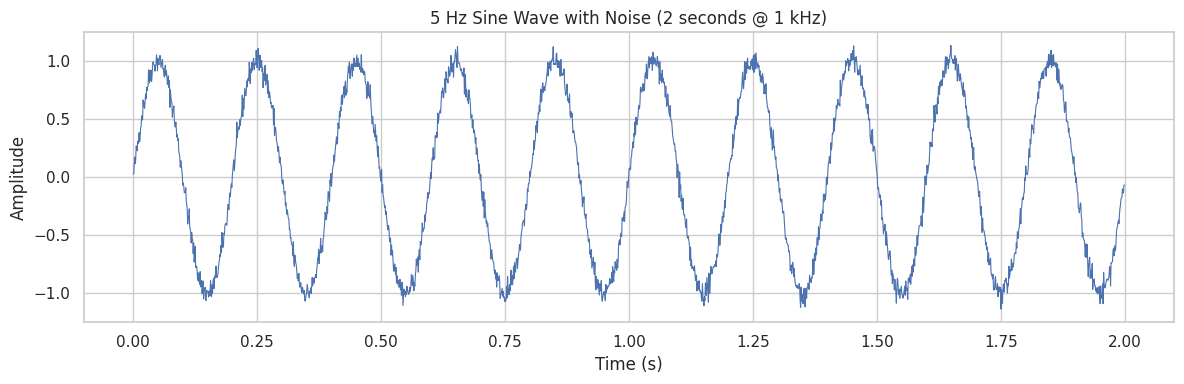

Series length: 2000
Value range:   [-1.135, 1.129]


In [23]:
# Generate a synthetic time series as a simple numpy array. It should represent
# a sine wave with minor noise. Generate a 2 second sample of a sin wave that has a 
# frequency of 5 Hz. Sample the sine wave at 1 kHz. Plot the series and print the range of values.
# Store your numpy array in `raw_series`.
import numpy as np
import matplotlib.pyplot as plt

# 1 kHz sample rate, 2 second duration → 2000 samples
t = np.linspace(0, 2, 2000, endpoint=False)  # time axis in seconds

# 5 Hz sine wave + small Gaussian noise
raw_series = np.sin(2 * np.pi * 5 * t) + np.random.normal(0, 0.05, size=len(t))

# Plot the series.
plt.figure(figsize=(12, 4))
plt.plot(t, raw_series, linewidth=0.8)
plt.title("5 Hz Sine Wave with Noise (2 seconds @ 1 kHz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

# Print the length and value range of the series.
print(f"Series length: {len(raw_series)}")
print(f"Value range:   [{raw_series.min():.3f}, {raw_series.max():.3f}]")

### Step 1.3: Temporal Split and Normalization

Split the data **temporally** (80% train, 10% validation, 10% test) and normalize using `MinMaxScaler` fitted only on the training portion.

#### Why a 3-Way Split?

Up to now in this course, you have worked with **2-way splits**: training data and test data.
The training set teaches the model, and the test set gives you an unbiased estimate of how
well the model generalizes to unseen data. That works fine when you train once and report
results. But in practice, you almost never train just one model. You:

* Try different architectures (RNN vs. LSTM vs. GRU)
* Tune hyperparameters (hidden size, learning rate, number of layers)
* Decide when to stop training (early stopping)
* Compare multiple runs and pick the best one

Every time you look at test-set performance to make one of these decisions, you are
**implicitly fitting to the test set**. Over many decisions, the test set leaks into your
choices. By the time you report final accuracy, you have no truly held-out data left —
your reported number is optimistic.

The **validation set** breaks this problem. It plays the role of a "practice test":

| Split | Purpose | When it is used |
|-------|---------|-----------------|
| **Train** | Gradient updates — the model learns from this data | Every training step |
| **Validation** | Hyperparameter tuning, architecture selection, early stopping | After each epoch, during development |
| **Test** | Final, one-time evaluation reported as the result | Once, after all decisions are made |

The critical rule: **the test set must not influence any decision during development**.
If you ever use test performance to choose a hyperparameter or restart training, you have
contaminated the test set and your final number is no longer trustworthy.

> **Q: Have we been incorrect in our 2-way split?**
> 
> **A:** Absolutely not. The 2-way is quite acceptable for many tasks. Just keep in mind that the accepted ML Engineer approach is a 3-way split. All training and evaluaton of individual models happens on the training and validation sets. Then, once a final model is determined to be acceptable by the validation sweep, the test set is used to report the final performance of the model.

#### For Time Series, the Split Must Be Temporal

Splits with ordered sequences and time series can NOT be random! Randomly assigning
timesteps to train/val/test would let the model see data from the *future* during training
and then be evaluated on data from the *past* — a form of look-ahead bias. Instead, we
split **by time**. A typical time series split looks like this:

```
|——————————— Train (80%) ———————————|—— Val (10%) ——|—— Test (10%) ——|
t=0                                                                 t=T
```

The model is trained on the earliest data, validated on the next chunk, and tested on the
most recent chunk — exactly mirroring real-world deployment where the future is always
unknown at the time of prediction.

In [24]:
# Split the series temporally (no shuffling!). Your aim is to create 
# (train_raw, val_raw, test_raw) splits by slicing raw_series in order,
# such that:
#   - train_raw: first 80% of the series
#   - val_raw: next 10% of the series
#   - test_raw: final 10% of the series
from sklearn.preprocessing import MinMaxScaler

n = len(raw_series)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

train_raw = raw_series[:train_end]
val_raw = raw_series[train_end:val_end]
test_raw = raw_series[val_end:]

print(f"Train: {len(train_raw)}  Val: {len(val_raw)}  Test: {len(test_raw)}")

# Normalize using MinMaxScaler fit on train only
scaler = MinMaxScaler()
# Scaler expects shape (n_samples, n_features), so reshape to (n, 1) then flatten back
train_scaled = scaler.fit_transform(train_raw.reshape(-1, 1)).flatten()
val_scaled = scaler.transform(val_raw.reshape(-1, 1)).flatten()
test_scaled = scaler.transform(test_raw.reshape(-1, 1)).flatten()

print(f"Train range after scaling: [{train_scaled.min():.3f}, {train_scaled.max():.3f}]")
print(f"Val range after scaling:   [{val_scaled.min():.3f}, {val_scaled.max():.3f}]")

Train: 1600  Val: 200  Test: 200
Train range after scaling: [0.000, 1.000]
Val range after scaling:   [-0.007, 1.001]


### Step 1.4: Modify `get_dataloaders` to support train/eval/test loaders

Open `src/my_engine/data.py`. Modify `get_dataloaders` to support train/eval/test loaders. This is what your new header should look like:

```python
def get_dataloaders(
    train_dataset: Dataset, 
    eval_dataset: Dataset = None, 
    test_dataset: Dataset = None,
    train_batch_size: int = 64, 
    eval_batch_size: int = 256, 
    test_batch_size: int = 256,
    collate_fn: Callable = None,
    num_workers: int = 0, 
    pin_memory: bool = False) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """
    Create DataLoader objects for training, validation, and testing datasets.
```

**TODO:** FILL IN THE REST... and pay attention to the new parameters! Return a tuple of (train_loader, val_loader, test_loader), where val_loader and test_loader could be None.


### Step 1.5: Create Datasets and DataLoaders

In [25]:
from lantern.data import TimeSeriesDataset, get_dataloaders

SEQ_LEN = 30
FORECAST_HORIZON = 1

# Create TimeSeriesDatasets for train, val, and test
train_ts_ds = TimeSeriesDataset(data=train_scaled, seq_len=SEQ_LEN, forecast_horizon=FORECAST_HORIZON)
val_ts_ds   = TimeSeriesDataset(data=val_scaled,   seq_len=SEQ_LEN, forecast_horizon=FORECAST_HORIZON)
test_ts_ds  = TimeSeriesDataset(data=test_scaled,  seq_len=SEQ_LEN, forecast_horizon=FORECAST_HORIZON)

print(f"Train dataset: {len(train_ts_ds)} samples")
print(f"Val dataset:   {len(val_ts_ds)} samples")
print(f"Test dataset:  {len(test_ts_ds)} samples")

# Inspect a single sample
x_sample, y_sample = train_ts_ds[0]
print(f"\nSingle sample:")
print(f"  X shape: {x_sample.shape}")   # Expected: (30, 1)
print(f"  y shape: {y_sample.shape}")   # Expected: (1,)

Train dataset: 1570 samples
Val dataset:   170 samples
Test dataset:  170 samples

Single sample:
  X shape: torch.Size([30, 1])
  y shape: torch.Size([1])


In [26]:
# Create all three DataLoaders in a single call — train, val, and test.
# Pass all three datasets so get_dataloaders returns (train_loader, val_loader, test_loader).
# No custom collate_fn needed for time series. Use the default batch sizes.
train_ts_loader, val_ts_loader, test_ts_loader = get_dataloaders(
    train_dataset=train_ts_ds,
    eval_dataset=val_ts_ds,
    test_dataset=test_ts_ds,
)

# Verify batch shapes for the training dataloader
# Verify batch shapes
batch_x, batch_y = next(iter(train_ts_loader))
print(f"Batch X shape: {batch_x.shape}")   # Expected: (64, 30, 1)
print(f"Batch y shape: {batch_y.shape}")   # Expected: (64, 1)

Batch X shape: torch.Size([64, 30, 1])
Batch y shape: torch.Size([64, 1])


In [27]:
show_note("Time series shapes confirmed: (batch, seq_len, num_features) for inputs and (batch, forecast_horizon) for targets. No padding or collate function needed — all windows have the same length by construction.")

In [28]:
show_todo("Work through Section 2: Understanding Recurrence")

## Section 2: Understanding Recurrence

Before using PyTorch's `nn.RNN`, let's build a single RNN cell from scratch to understand what happens at each time step. This is analogous to manually computing matrix multiplications before using `nn.Linear` — it builds intuition.

### Step 2.1: Manual RNN Cell

Implement a single recurrence step: $h_t = \tanh(W_{ih} x_t + W_{hh} h_{t-1} + b_h)$

In [29]:
show_todo("Implement a manual RNN cell and trace the hidden state through a short sequence")

In the cell below, you will implement the inner workings of a simple vanilla RNN cell from scratch, processing a short input sequence manually step-by-step. This exercise is meant to help you understand the core mechanics of recurrence: how the hidden state is updated at each time step by combining the current input with the previous hidden state through matrix multiplications and a nonlinearity. By explicitly following hidden state values through a sequence, you'll gain intuition about how information is carried and transformed through the network before using high-level PyTorch RNN modules.

In [30]:
# Define dimensions for our manual RNN
input_size = 1     # Each time step is a single scalar (e.g., temperature)
hidden_size = 4    # Small hidden state for visualization

# Initialize weights manually (small random values)
torch.manual_seed(42)
W_ih = torch.rand((hidden_size, input_size))    # (hidden, input)
W_hh = torch.rand((hidden_size, hidden_size))   # (hidden, hidden)
b_h = torch.rand((hidden_size,))                        # (hidden,)

# Create a short input sequence (5 time steps, 1 feature each)
x_seq = torch.tensor([[0.1], [0.5], [0.9], [0.3], [-0.2]], dtype=torch.float32)
print(f"Input sequence shape: {x_seq.shape}")  # (5, 1)

# Initialize hidden state to zeros
h = torch.zeros((hidden_size,))
print(f"Initial hidden state: {h}")

# Loop through the sequence, computing h_t at each step
# Store the initial hidden state for reference
hidden_states = [h.clone()]

# Loop over each time step in the input sequence
for t in range(len(x_seq)):
    # Get the input vector at time step t (shape: input_size,)
    x_t = x_seq[t]  # (input_size,)
    
    # Compute the new hidden state using the RNN recurrence equation:
    # h_t = tanh(W_ih @ x_t + W_hh @ h_{t-1} + b_h)
    h = torch.tanh(W_ih @ x_t + W_hh @ hidden_states[t] + b_h)
    
    # Save a copy of the updated hidden state for later visualization
    hidden_states.append(h.clone())
    
    # Print input and new hidden state for this time step
    print(f"t={t}: x_t={x_t.item():.2f}  h_t={h.detach().numpy().round(4)}")

Input sequence shape: torch.Size([5, 1])
Initial hidden state: tensor([0., 0., 0., 0.])
t=0: x_t=0.10  h_t=[0.3433 0.4876 0.3232 0.7295]
t=1: x_t=0.50  h_t=[0.9468 0.9655 0.9241 0.9849]
t=2: x_t=0.90  h_t=[0.9954 0.9989 0.9961 0.9993]
t=3: x_t=0.30  h_t=[0.9884 0.9973 0.9952 0.9981]
t=4: x_t=-0.20  h_t=[0.9719 0.9932 0.9928 0.9948]


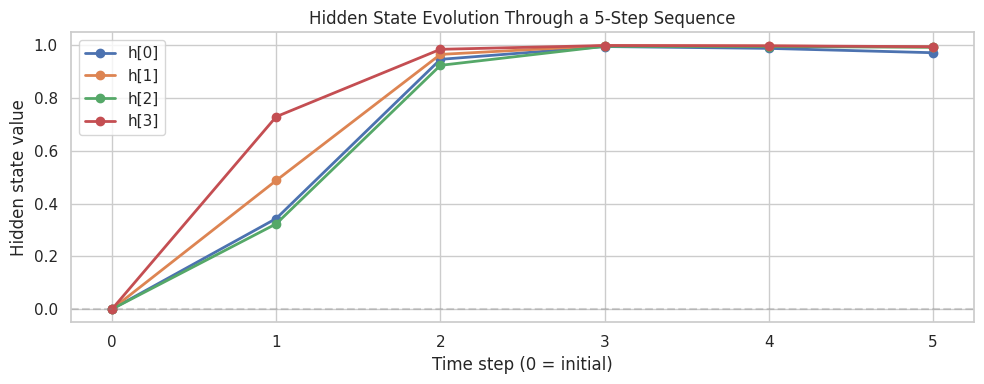

In [31]:
# Visualize how each dimension of the hidden state evolves over time
hidden_matrix = torch.stack(hidden_states).detach().numpy()  # (6, 4)

fig, ax = plt.subplots(figsize=(10, 4))
for dim in range(hidden_size):
    ax.plot(hidden_matrix[:, dim], marker='o', label=f"h[{dim}]", linewidth=2)
ax.set_xlabel("Time step (0 = initial)")
ax.set_ylabel("Hidden state value")
ax.set_title("Hidden State Evolution Through a 5-Step Sequence")
ax.legend(loc="best")
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** Each dimension of the hidden state responds to the sequence of inputs in a different way. Some dimensions increase with large inputs, others decrease. The hidden state at the final time step is a **compressed summary** of the entire sequence — it "remembers" the pattern of inputs.

This is exactly what `nn.RNN` does internally, except it handles batches, multiple layers, and gradient computation automatically.

### Step 2.2: Verify the shapes of `nn.RNN`

Let's verify the shapes that `nn.RNN` produces. Understanding these shapes is critical for connecting the RNN output to a classification or regression head.

In [32]:
# Create a simple nn.RNN and trace shapes through it
rnn_layer = nn.RNN(input_size=1, hidden_size=8, num_layers=1, batch_first=True)

# Simulate a batch of 4 sequences, each of length 30, with 1 feature
dummy_input = torch.randn(4, 30, 1)  # (batch, seq_len, input_size)

output, h_n = rnn_layer(dummy_input)

print("nn.RNN Shape Reference:")
print(f"  Input:       {dummy_input.shape}")    # (4, 30, 1)
print(f"  Output:      {output.shape}")          # (4, 30, 8) — hidden state at every time step
print(f"  h_n:         {h_n.shape}")             # (1, 4, 8) — final hidden state only (num_layers, batch, hidden)
print()
print("For many-to-one tasks (classification, one-step forecast):")
print(f"  Use h_n[-1]:  {h_n[-1].shape}")        # (4, 8) — last layer's final hidden
print(f"  Or output[:, -1, :]: {output[:, -1, :].shape}")  # (4, 8) — same thing for single layer
print()
print(f"  Verify equal: {torch.allclose(h_n[-1], output[:, -1, :])}")

nn.RNN Shape Reference:
  Input:       torch.Size([4, 30, 1])
  Output:      torch.Size([4, 30, 8])
  h_n:         torch.Size([1, 4, 8])

For many-to-one tasks (classification, one-step forecast):
  Use h_n[-1]:  torch.Size([4, 8])
  Or output[:, -1, :]: torch.Size([4, 8])

  Verify equal: True


In [33]:
show_note("For a single-layer RNN, h_n[-1] and output[:, -1, :] give the same result — the final hidden state. For multi-layer RNNs, h_n gives you the final state from EACH layer, while output only gives the top layer's states at every time step.")

In [34]:
show_todo("Work through Section 3: Vanilla RNN in PyTorch (Engine Extension)")

## Section 3: Vanilla RNN in PyTorch

Time to extend the engine! We will add new config fields and a new model class, following the same pattern as hw08 (where you added BoE and TextCNN1D). However, to prepare ahead, we'll also add support for a couple of highly similar models for sequential and time series learning: 

### Comparing RNN architectures

Recurrent Neural Networks (RNNs) were among the first architectures designed to handle 
sequential data by maintaining a **hidden state** (that is, a compact memory of what the network 
has seen so far) that is updated at every time step. The simplest form, the **vanilla RNN**, 
passes this hidden state through a single tanh activation at each step, making it conceptually 
straightforward and computationally cheap. In PyTorch, this is represented by the `nn.RNN` module. 
Training vanilla RNNs over long sequences reveals a fundamental weakness: gradients must be 
multiplied repeatedly through time during backpropagation, causing them to shrink exponentially and effectively vanish before reaching early time steps. As we noted before, the **vanishing gradient problem** prevents 
vanilla RNNs from learning long-range dependencies, severely limiting their practical usefulness on most real-world 
sequence tasks.

To address these limitations, two gated architectures emerged that remain widely used today. 
The **Long Short-Term Memory (LSTM)**, introduced by Hochreiter and Schmidhuber in 1997, adds 
a separate **cell state** alongside the hidden state and uses three learnable gates — input, 
forget, and output — to precisely control what information is stored, discarded, or exposed at 
each time step. This architecture largely solves the vanishing gradient problem and became the 
dominant sequence model for over a decade, powering advances in speech recognition, machine 
translation, and language modeling. The **Gated Recurrent Unit (GRU)**, proposed by Cho et al. 
in 2014, simplifies the LSTM by collapsing the cell state and hidden state into one and reducing 
to just two gates — reset and update. The result is a lighter model with fewer parameters that 
trains faster and often matches LSTM performance, making it a strong default choice for many 
practical sequence learning tasks.

### If RNNs are so limited, do they have any utility? 
Yes! basic RNNs are genuinely useful, just for a narrower class of problems than their gated cousins. 
Their limitations are real, but they are not a reason not to learn about them. 

You should be concluding that the infamous **vanishing gradient problem** is the primary challenge here. For RNNs, it really only bites you when dependencies span **many time steps**. For short sequences where dependencies only depend on a few previous time steps, vanilla RNNs are competitive and considerably cheaper to train. Where are they useful?

- **Short-horizon time series** — e.g., predicting the next value in a smooth signal where only the last few steps matter
- **Character-level text generation** — local character patterns (spelling, morphology) are short-range by nature 
- **Simple classification on fixed-length sequences** — sentiment on short phrases, gesture recognition from brief motion windows
- **Online/streaming signal processing** — when latency and memory footprint matter more than accuracy on long contexts
- **Pedagogical baseline** — its simplicity makes it the right starting point for teaching BPTT, hidden state dynamics, and why gates were needed in the first place

> I highly recommend the following [GeeksForGeeks article that compares RNN, LSTM, GRU and Transformers](https://www.geeksforgeeks.org/deep-learning/rnn-vs-lstm-vs-gru-vs-transformers/)

**IMPORTANT:** Even on tasks where LSTMs and GRUs ultimately win, vanilla RNNs often perform **surprisingly close** on short or well-preprocessed sequences. *Strive to design your model with complexity matched to the task complexity.* This is so important, and applies to all of machine learning models! You've heard this already, and you'll hear it through our exploration of transformers.

### Step 3.1: Add RNN Fields to `ModelConfig` in `config.py`

Open `src/my_engine/config.py`. Add the following fields to `ModelConfig`. These have defaults that preserve backward compatibility. Also

```python
@dataclass
class ModelConfig:
    """
        ...

        model_type: Which model to build. Supported values:
            - "mlp"     — MLP_Model (fully connected classifier/regressor)
            - "cnn"     — CNN_Model (2D convolutional network for images)
            - "bow"     — BagOfEmbeddings (embedding + mean pooling + classifier for text)
            - "textcnn" — TextCNN1D (1D convolutional text classifier with multiple filter sizes)
            - "rnn"     — RNNModel (vanilla RNN, LSTM or GRU)

        ...
    """
    ...
    # --- RNN fields ---
    rnn_hidden_size: int = 64           # Hidden state dimensionality for RNN layers
    rnn_num_layers: int = 1             # Number of stacked RNN layers
    bidirectional: bool = False         # If True, use bidirectional RNN
    rnn_type: str = "rnn"              # "rnn" for vanilla RNN, "lstm" for LSTM, "gru" for GRU
    clip_grad_norm: float = 0.0        # Max gradient norm for clipping (0 = disabled)
```

* `rnn_hidden_size`: The dimensionality of the hidden state vector. Analogous to `embedding_dim` for text.
* `rnn_num_layers`: Number of stacked RNN layers. Deeper RNNs can learn more complex patterns.
* `bidirectional`: If True, the RNN reads the sequence both forward and backward, doubling the effective hidden size.
* `rnn_type`: Supports both `"rnn"` and `"lstm"` so we can reuse the same model class in Week 10.
* `clip_grad_norm`: Maximum gradient norm for gradient clipping. Set to 0 to disable.

**TODO:** Update the class docstring to cover these new fields


### Step 3.2: Implement `RNNModel` in `model.py`

Add the following `RNNModel` class to `src/my_engine/model.py`. This model is designed to work directly with **continuous inputs** (time series). We will build a separate `TextRNNModel` later for text (which adds an embedding layer).

```python
class RNNModel(nn.Module):
    """Vanilla RNN (or LSTM or GRU) for regression or classification on continuous sequences.

    This model processes sequence data (such as time series) using a recurrent neural network backbone (RNN, LSTM, or GRU),
    followed by a fully connected classifier or regressor head. It does not perform embedding or tokenization and is assumed
    to receive raw float inputs.

    Architecture:
        Input shape: (batch_size, seq_len, input_size)
            └──> nn.RNN / nn.LSTM / nn.GRU → (batch_size, seq_len, num_directions * hidden_size)
            └──> Final hidden state extraction → (batch_size, hidden_size * num_directions)
            └──> Fully connected head → (batch_size, num_outputs)

        Here ``num_directions`` is 1 for unidirectional and 2 for bidirectional RNNs (matching PyTorch).

    Example:
        >>> from src.my_engine.config import ModelConfig
        >>> config = ModelConfig(
        ...     model_type="rnn",
        ...     rnn_hidden_size=32,
        ...     rnn_num_layers=2,
        ...     bidirectional=True,
        ...     rnn_type="lstm",
        ...     hidden_units=[16],
        ...     dropout=[0.1]
        ... )
        >>> model = RNNModel(input_size=8, num_outputs=3, config=config)
        >>> x = torch.randn(4, 22, 8)  # batch of 4, sequence length 22, 8 features
        >>> y = model(x)  # (4, 3)

    Attributes:
        input_size (int): Number of input features per time step (e.g., 1 for univariate).
        num_outputs (int): Number of output values (1 for regression, C for classification).
        config (ModelConfig): Configuration object.
        rnn (nn.Module): The RNN/LSTM/GRU module.
        output_head (nn.Sequential): Sequential fully connected head after the recurrent backbone.
    """

    def __init__(self, input_size: int, num_outputs: int, config: ModelConfig) -> None:
        """Build the recurrent backbone and output head.

        Args:
            input_size: Number of input features per time step (e.g., ``1`` for a
                univariate series).
            num_outputs: Number of outputs (``1`` for regression, ``C`` for
                ``C``-way classification).
            config: Model configuration. Uses ``rnn_hidden_size``,
                ``rnn_num_layers``, ``bidirectional``, ``rnn_type`` (``"rnn"``,
                ``"lstm"``, or ``"gru"``), and ``hidden_units`` / ``dropout`` for
                the fully connected head built by ``_construct_fc_layers``.

        Raises:
            ValueError: If ``config.model_type`` is not ``"rnn"``.
            ValueError: If ``config.rnn_type`` is not one of ``"rnn"``, ``"lstm"``, or ``"gru"``.

        """
        super().__init__()

        # TODO: Validate config.model_type is "rnn". If not, throw a ValueError
        ???
        
        # TODO: Store self copies of parameters
        ???

        # TODO: Determine if bidirectional is set, so you know how many directions your RNN will have.


        # Build the recurrent backbone. Choose the correct nn module depending on rnn_type. 
        # Throws a ValueError if not "rnn", "lstm" or "gru"
        if config.rnn_type == "lstm":
            rnn_module = nn.LSTM
        elif config.rnn_type == "gru":
            rnn_module = nn.GRU
        elif config.rnn_type == "rnn":
            rnn_module = nn.RNN
        else:
            raise ValueError(f"Invalid rnn_type: {config.rnn_type}. Supported: 'rnn', 'lstm', 'gru'.")
        
        # TODO: Instantiate your recurrent module ("self.rnn") using the chosen rnn_module. Make sure
        #       to use input_size, hidden_size, num_layers, batch_first, and bidirectional from config.
        self.rnn = rnn_module(
            ???
        )



        # TODO: The output head receives the concatenated final hidden state(s).
        #       Its input dimension is hidden_size * num_directions.
        head_input_size = config.rnn_hidden_size * num_directions

        # TODO: Call _construct_fc_layers to create a classifier/regressor head after the RNN
        self.classifier_head = ???

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Encode each sequence and apply the output head.

        For LSTM, only the last hidden state ``h_n`` is used (not the cell state).
        For bidirectional models, the last forward and backward states of the top
        layer are concatenated before the head.

        Args:
            x: Float tensor of shape ``(batch, seq_len, input_size)``.

        Returns:
            Float tensor of shape ``(batch, num_outputs)``.
        """
        # TODO: Run through the recurrent backbone (RNN, LSTM, or GRU)
        ???

        # Extract the last hidden state(s) depending on RNN type
        if self.config.rnn_type == "lstm":
            # LSTM returns a tuple (h_n, c_n)
            h_n, _ = hidden
        else:
            # GRU and vanilla RNN return h_n directly
            h_n = hidden
        
        # TODO: h_n shape: (num_layers * num_directions, batch, hidden_size)
        if self.config.bidirectional:
            # Forward final state: h_n[-2], Backward final state: h_n[-1]
            # Both have shape (batch, hidden_size), so we cat along dim=1
            ???
        else:
            # Use the last layer's final hidden state (shape: batch, hidden_size)
            ???
        
        # TODO: Pass through classifier head
        return ???
        

    def num_parameters(self) -> tuple[int, int]:
        """Count total and trainable parameters in this module and submodules.

        Returns:
            A tuple ``(total_params, trainable_params)`` where both counts are
            non-negative integers.
        """
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable

    def get_architecture_config(self) -> dict:
        """Return a JSON-serializable description of the architecture.

        Returns:
            A dictionary with keys:

            * ``model_class``: The string ``"RNNModel"``.
            * ``input_size``: Features per time step.
            * ``num_outputs``: Size of the head output.
            * ``config``: The full ``ModelConfig`` as a plain dict (via
              ``dataclasses.asdict``).
        """
        return {
            "model_class": "RNNModel",
            "input_size": self.input_size,
            "num_outputs": self.num_outputs,
            "config": asdict(self.config),
        }

    def __str__(self) -> str:
        """Return a short, human-readable summary of hyperparameters.

        Returns:
            A string listing ``rnn_type``, directionality (uni/bi), ``input_size``,
            ``rnn_hidden_size``, ``rnn_num_layers``, and ``num_outputs``.
        """
        direction = "bi" if self.config.bidirectional else "uni"
        return (
            f"RNNModel(type={self.config.rnn_type}, {direction}, "
            f"input={self.input_size}, hidden={self.config.rnn_hidden_size}, "
            f"layers={self.config.rnn_num_layers}, out={self.num_outputs})"
        )

    def __repr__(self) -> str:
        """Return the same string as :meth:`__str__` for notebook and debugger display.

        Returns:
            Identical to :meth:`__str__`.
        """
        return self.__str__()

```

Don't forget to update the import at the top of `model.py` if needed.

### Step 3.3: Register `"rnn"` in `build_model` (`utils.py`)


Open `src/my_engine/utils.py`. Add `RNNModel` to the import and a new branch for `model_type == "rnn"`. For the RNN, `input_spec` is an integer representing the number of features per time step.

```python
from src.my_engine.model import MLP_Model, CNN_Model, BagOfEmbeddings, TextCNN1D, RNNModel

def build_model(input_spec, num_outputs, config: ModelConfig):
    """
        ...
        Args:
        input_spec (int or list/tuple of int): 
            - For "mlp": int, total number of input features (flattened)
            - For "cnn": (height, width) tuple or list specifying the 2D input image shape (excluding channels)
            - For "bow": int, total number of input features (flattened)
            - For "textcnn": (num_filters, filter_sizes) tuple or list specifying the 1D input sequence shape
            - For "rnn": int > 0, number of features per time step
        ...
    """
    ...
    elif config.model_type == "rnn":
        if not isinstance(input_spec, int) or input_spec <= 0:
            raise ValueError("RNN requires input_spec as int > 0 (input_size = features per time step).")
        return RNNModel(input_size=input_spec, num_outputs=num_outputs, config=config)
    ...
```



### Step 3.4: Add Full Checkpoint Loader Support in `utils.py`

Your `Trainer` already saves checkpoints for all model families, including RNN. The missing piece is `load_model_from_checkpoint(...)` in `src/my_engine/utils.py`, which currently only reconstructs MLP/CNN.

Let's update `utils.py` so checkpoint loading works for **all** supported models (`mlp`, `cnn`, `bow`, `textcnn`, `rnn`).

#### 1) Extend imports

At the top of `utils.py`, include the block config dataclasses so CNN configs can be reconstructed:

```python
from src.my_engine.config import (
    ModelConfig,
    TrainerConfig,
    ConvBlockConfig,
    ResidualBlockConfig,
)
```

#### 2) Add a helper to rebuild `ModelConfig` from checkpoint metadata

Some checkpoints store `conv_blocks` as plain dicts. Convert those dicts back into dataclass objects before constructing `ModelConfig`. Add the following method in `utils.py`, after your `load_model_from_checkpoint` function:

```python
def _rebuild_model_config(config_dict: dict) -> ModelConfig:
    """Rehydrate ModelConfig from checkpoint-safe dictionaries."""
    cfg = dict(config_dict)

    if "conv_blocks" in cfg and isinstance(cfg["conv_blocks"], list):
        rebuilt_blocks = []
        for block in cfg["conv_blocks"]:
            if isinstance(block, dict):
                block_type = block.get("block_type", "conv")
                block_payload = {k: v for k, v in block.items() if k != "block_type"}
                if block_type == "residual":
                    rebuilt_blocks.append(ResidualBlockConfig(**block_payload))
                else:
                    rebuilt_blocks.append(ConvBlockConfig(**block_payload))
            else:
                rebuilt_blocks.append(block)
        cfg["conv_blocks"] = rebuilt_blocks

    return ModelConfig(**cfg)
```

#### 3) Update `load_model_from_checkpoint(...)` 

Use the architecture metadata to infer model type (`model_type` preferred, fallback to `model_class`), build the right model, then load `model_state_dict`. Starting with a few lines that should be in your function, add the additional lines:

```python
    ...
    model_type = arch.get("model_type")

    if model_type is None:
        model_class = arch.get("model_class")
        dict_class_to_type = {
            "MLP_Model": "mlp",
            "CNN_Model": "cnn",
            "BagOfEmbeddings": "bow",
            "TextCNN1D": "textcnn",
            "RNNModel": "rnn",
        }
        model_type = dict_class_to_type.get(model_class)

    if model_type is None:
        raise ValueError(
            "Could not determine model type from checkpoint architecture metadata"
        )

    config = _rebuild_model_config(arch["config"])

    if model_type == "mlp":
        model = MLP_Model(
            num_inputs=arch["num_inputs"],
            num_outputs=arch["num_outputs"],
            config=config,
        )
    elif model_type == "cnn":
        model = CNN_Model(
            input_height=arch["input_height"],
            input_width=arch["input_width"],
            num_outputs=arch["num_outputs"],
            config=config,
        )
    elif model_type == "bow":
        model = BagOfEmbeddings(
            num_outputs=arch["num_outputs"],
            config=config,
        )
    elif model_type == "textcnn":
        model = TextCNN1D(
            num_outputs=arch["num_outputs"],
            config=config,
        )
    elif model_type == "rnn":
        model = RNNModel(
            input_size=arch["input_size"],
            num_outputs=arch["num_outputs"],
            config=config,
        )
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    return model
```


### Step 3.5: Add Comprehensive RNN Sweep Support in `sweep.py`

To make sure your Section 3 engine extensions are sweep-ready, add full RNN support to `make_train_sweep(...)` in `src/my_engine/sweep.py`.
This is required if you want to run a true `wandb sweep` + `wandb agent` later instead of a manual loop.

Follow these steps to update inside `train_sweep()` inside `make_train_sweep(...)`:

```python

# Read all RNN fields from wandb.config using ModelConfig defaults.
rnn_hidden_size = getattr(config, "rnn_hidden_size", default_model_config.rnn_hidden_size)
rnn_num_layers = getattr(config, "rnn_num_layers", default_model_config.rnn_num_layers)
bidirectional = getattr(config, "bidirectional", default_model_config.bidirectional)
rnn_type = getattr(config, "rnn_type", default_model_config.rnn_type)
clip_grad_norm = getattr(config, "clip_grad_norm", default_model_config.clip_grad_norm)

# Choose loss by config ("mse" for regression, "cross_entropy" for classification).
loss_name = getattr(config, "loss_name", "cross_entropy")
```

Add the support for "rnn" with run naming

```python
if model_type == "textcnn":
    ...
elif model_type == "bow":
    ...
elif model_type == "rnn":
    run.name = (
        f"{model_type}_bs{trainer_batch_size}_lr{learning_rate:.5f}"
        f"_hs{rnn_hidden_size}_L{rnn_num_layers}"
        f"_bi{int(bidirectional)}_{rnn_type}_wd{weight_decay:.5f}"
    )
else:
    ...
```

Pass the new RNN fields into ModelConfig(...), and build a new criterion for the sweep config. This is needed
for the work we'll be doing with time series, which needs regression compliant loss 

```python
model_config = ModelConfig(
    model_type=model_type,
    hidden_units=hidden_units,
    dropout=dropout,
    conv_blocks=conv_blocks,
    in_channels=in_channels,
    use_GAP=use_GAP,
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    padding_idx=padding_idx,
    freeze_embeddings=freeze_embeddings,
    num_filters=num_filters,
    filter_sizes=filter_sizes,
    # --- RNN support ---
    rnn_hidden_size=rnn_hidden_size,
    rnn_num_layers=rnn_num_layers,
    bidirectional=bidirectional,
    rnn_type=rnn_type,
    clip_grad_norm=clip_grad_norm,
)

# Build criterion from the sweep config.
if loss_name == "mse":
    criterion = nn.MSELoss()
elif loss_name == "cross_entropy":
    criterion = nn.CrossEntropyLoss()
else:
    raise ValueError(f"Unsupported loss_name: {loss_name}")
```

Check to see how the criterion is set up. You may have a line that says `criterion = nn.CrossEntropyLoss()`` that was silently overwriting the criterion built from loss_name. This meant MSE loss was never actually used for regression sweeps. So, if you have that line, remove it!

After these additions, your sweep config can now support these new entries in your configuration dictionary:
- `model_type: "rnn"`
- `rnn_hidden_size`, `rnn_num_layers`, `bidirectional`, `rnn_type`, `clip_grad_norm`
- `loss_name` (`"mse"` for Section 4 forecasting, `"cross_entropy"` for classification tasks)

### Step 3.6: Shape Verification

Always verify shapes before training. Create a dummy batch and confirm the output dimensions.

In [35]:
show_todo("Verify that your RNNModel produces the correct output shape")

In [36]:
from lantern.config import ModelConfig, ModelType
from lantern.model import RNNModel
from lantern.utils import build_model

# Create a ModelConfig for a vanilla RNN, rnn_hidden_size=32, rnn_num_layers=1, 
# bidirectional=False, rnn_type="rnn", hidden_units=[16], dropout=[0.1]
rnn_config = ModelConfig(
    model_type=ModelType.RNN,
    rnn_hidden_size=32, 
    rnn_num_layers=1, 
    bidirectional=False, 
    rnn_type="rnn", 
    hidden_units=[16], 
    dropout=[0.1]
)

# Instantiate an RNNModel for univariate time series forecasting (1 input, 1 output)
rnn_model = build_model(input_spec=1, num_outputs=1, config=rnn_config)
print(rnn_model)

total, trainable = rnn_model.num_parameters()
print(f"\nTotal parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")

# Pass a dummy batch through and check the output shape
dummy = torch.randn(8, 30, 1)  # (batch=8, seq_len=30, features=1)
out = rnn_model(dummy)
print(f"\nInput shape:  {dummy.shape}")    # (8, 30, 1)
print(f"Output shape: {out.shape}")        # Expected: (8, 1)
assert out.shape == (8, 1), f"Shape mismatch — expected (8, 1), got {out.shape}"
print("Shape check passed!")

RNNModel(type=rnn, uni, input=1, hidden=32, layers=1, out=1)

Total parameters:     1,665
Trainable parameters: 1,665

Input shape:  torch.Size([8, 30, 1])
Output shape: torch.Size([8, 1])
Shape check passed!


In [37]:
show_warning("Do not proceed until the shape check passes. If RNNModel is not importable, verify your additions to model.py and utils.py.")

In [38]:
show_todo("Work through Section 4: Time Series Forecasting")

## Checkpoint

## Section 4: Time Series Forecasting

Now let's train the RNN on our synthetic sine wave and see if it can predict the next value. This is the time series analog of the sentiment classification you did in hw08 — same Trainer, same W&B, different data and loss function.


### Step 4.1: Add Regression Metrics to the Engine

The `METRIC_REGISTRY` in `trainer.py` currently supports only classification metrics
(`accuracy`, `f1`, `precision`, `recall`). Before we can track regression metrics during
training, you need to extend the engine in three places.

**Your task — extend `src/my_engine/trainer.py`:**

**1. Add three new entries to `METRIC_REGISTRY`:**

The registry is a plain dict near the top of the file that maps string names to torchmetrics
classes. Add:
- `"mae"` → `torchmetrics.MeanAbsoluteError`
- `"mse"` → `torchmetrics.MeanSquaredError`
- `"r2"` → `torchmetrics.R2Score`

**2. Update your `_build_metric_collections` helper method to handle `task="regression"`:**

This method builds the `MetricCollection` objects used during training. Read it carefully —
it currently does two things that break for regression:

- The guard at the top raises `ValueError` for any task that isn't `"multiclass"` or
  `"binary"`. Add `"regression"` to that check.

- For every metric it constructs, it passes `task=task` as a keyword argument (and for
  multiclass, also `num_classes` and `average`). This works for torchmetrics classification
  metrics, but **regression metrics like `MeanAbsoluteError` and `R2Score` accept no `task`
  argument at all** — passing one will raise a `TypeError`. When `task == "regression"`,
  build an empty `kwargs` dict instead and skip all the classification-specific arguments.

**3. Update `train_one_epoch` and `validate` to pass the right values to the metrics:**

Both methods currently compute `preds = outputs.argmax(dim=1)` before calling
`self.train_metrics.update(preds, targets)`. Argmax makes sense for classification
(picking the highest-scoring class), but for regression the model already outputs a scalar
prediction — we want to pass that raw value directly. When `task == "regression"`, call
`.update()` with `outputs.squeeze()` (remove the trailing size-1 dimension) and
`targets.float()` (regression metrics expect float tensors). Keep the existing argmax path
for classification tasks.

**4. Update the docstring of `MetricsConfig` in `config.py` to show the new torchmetrics task types.**

Be sure to add `"multiclass", "binary", and "regression"`, and show the new tasks of `"mae"`, `"mse"`, and `"r2"`.



In [39]:
show_todo("Step 4.1 — Extend METRIC_REGISTRY and _build_metric_collections in trainer.py to support regression metrics")

### Step 4.2: Configure and Train a Regression Model for Time Series Forecasting

In this step, you'll set up and train a recurrent neural network (RNN) for predicting future values in a time series (i.e., a regression problem). This involves:

1. Setting up a `ModelConfig` for an RNN.
2. Choosing a suitable `TrainerConfig`, including a batch size and optimizer.
3. Building the model using `build_model(...)`.
4. Creating train and validation DataLoaders for your time series data.

Make sure you use the correct regression metrics:
- Set up your `MetricsConfig` with `task="regression"` and metrics `"mse"`

Key points:
- The model should predict a single future value per sequence (output size 1).
- The metrics configuration must match a regression task (not classification!).
- The loss function should be Mean Squared Error (`nn.MSELoss`).
- Training is performed on the appropriate device (`accel_device`).

Follow the cell structure below, filling in the model, dataloaders, and metrics configuration. Then, instantiate `Trainer` and train the model!

In [40]:
from lantern.config import TrainerConfig, MetricsConfig
from lantern.utils import build_model, make_optimizer
from lantern.trainer import Trainer

In [41]:
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs = 30
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs = 10
else:
    num_epochs = 0

# Configure the model for time series forecasting
ts_model_config = ModelConfig(
    model_type=ModelType.RNN,
    rnn_hidden_size=64,
    rnn_num_layers=1,
    rnn_type="rnn",
    hidden_units=[32],
    dropout=[0.1],
)

ts_trainer_config = TrainerConfig(
    trainer_batch_size=64,
    evaluator_batch_size=256,
    learning_rate=1e-3,
    optimizer_name="adam",
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=num_epochs,
)

# Build the model using build_model
ts_model = build_model(
    input_spec=1,         # 1 feature per time step (univariate)
    num_outputs=1,        # Predict 1 future value
    config=ts_model_config,
)
print(ts_model)
print(f"Parameters: {ts_model.num_parameters()}")

RNNModel(type=rnn, uni, input=1, hidden=64, layers=1, out=1)
Parameters: (6401, 6401)


In [42]:
# Create DataLoaders for training — unpack all three (test_loader not used here)
train_ts_loader, val_ts_loader, test_ts_loader = get_dataloaders(
    train_dataset=train_ts_ds,
    eval_dataset=val_ts_ds,
    test_dataset=test_ts_ds,
)

In [43]:
run_ts = None
if DO_WANDB_LOGGING and num_epochs > 0:
    run_ts = wandb.init(
        project="csci357-hw09-timeseries",
        name=f"{user_initials}-rnn-sine",
        reinit=True,
        settings=wandb.Settings(x_stats_sampling_interval=2.0, silent=True)
    )

# Train with MSELoss (this is regression, not classification!). ALso log "mae" in MetricsConfig
with Trainer(
    model=ts_model,
    optimizer=make_optimizer(ts_model.parameters(), ts_trainer_config),
    criterion=nn.MSELoss(),
    config=ts_trainer_config,
    run=run_ts,
    metrics_config=MetricsConfig(task="regression", names=["mae"]),
) as trainer:
    ts_results = trainer.fit(train_ts_loader, val_ts_loader)

print(f"\nTime Series Results: {ts_results}")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 0:
Train Mae=0.2778  Val Mae=0.2070
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Mae=0.1146  Val Mae=0.0414
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Mae=0.0509  Val Mae=0.0300
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Mae=0.0485  Val Mae=0.0256
Epoch 4:
Train Mae=0.0426  Val Mae=0.0221
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Mae=0.0413  Val Mae=0.0253
Epoch 6:
Train Mae=0.0395  Val Mae=0.0217
Epoch 7:
Train Mae=0.0401  Val Mae=0.0215

Time Series Results: {'num_epochs': 8, 'train_mae': 0.04013791307806969, 'val_mae': 0.021482758224010468}


### Step 4.3: Evaluate and Visualize Predictions

The best way to evaluate a time series model is to **plot predictions against ground truth**. We also compute standard regression metrics: MAE (Mean Absolute Error) and RMSE (Root Mean Squared Error).

In [44]:
show_todo("Generate predictions on the test set and visualize them")

In [45]:
# Generate predictions on the test set

ts_model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_x, batch_y in test_ts_loader:
        batch_x = batch_x.to(ts_trainer_config.device)
        pred = ts_model(batch_x).cpu()
        all_preds.append(pred)
        all_targets.append(batch_y)

preds = torch.cat(all_preds).squeeze().numpy()
targets = torch.cat(all_targets).squeeze().numpy()

# Compute metrics
mae = np.mean(np.abs(preds - targets))
rmse = np.sqrt(np.mean((preds - targets) ** 2))
print(f"Test MAE:  {mae:.6f}")
print(f"Test RMSE: {rmse:.6f}")

Test MAE:  0.022006
Test RMSE: 0.028128


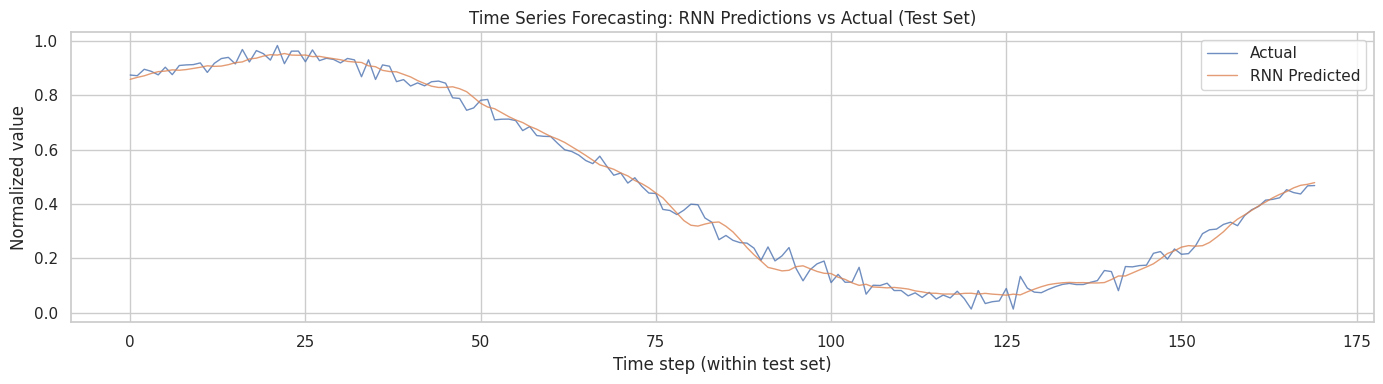

In [46]:
# Plot predicted vs actual
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(targets, label="Actual", linewidth=1.0, alpha=0.8)
ax.plot(preds, label="RNN Predicted", linewidth=1.0, alpha=0.8)
ax.set_title("Time Series Forecasting: RNN Predictions vs Actual (Test Set)")
ax.set_xlabel("Time step (within test set)")
ax.set_ylabel("Normalized value")
ax.legend()
plt.tight_layout()
plt.show()

### Step 4.4: Compare to Naive Baseline

A **naive baseline** for one-step-ahead forecasting is the **persistence model**: predict that the next value equals the current value ($\hat{y}_{t+1} = y_t$). Any useful model should beat this baseline.

In [47]:
# Compute the naive baseline (last value carried forward)
# The naive prediction for step t+1 is the value at step t
naive_preds = test_scaled[SEQ_LEN - 1 : SEQ_LEN - 1 + len(targets)]
# Compute MAE and RMSE for the naive baseline
naive_mae = np.mean(np.abs(naive_preds - targets))
naive_rmse = np.sqrt(np.mean((naive_preds - targets) ** 2))

print(f"RNN   — MAE: {mae:.6f}  RMSE: {rmse:.6f}")
print(f"Naive — MAE: {naive_mae:.6f}  RMSE: {naive_rmse:.6f}")
improvement = (1 - mae / naive_mae) * 100
print(f"RNN improvement over naive: {improvement:.1f}%")

RNN   — MAE: 0.022006  RMSE: 0.028128
Naive — MAE: 0.024800  RMSE: 0.033372
RNN improvement over naive: 11.3%


### Reflective Exercise 4-A: Time Series Forecasting

**R1:** Why do we use `MSELoss` for time series forecasting instead of `CrossEntropyLoss`? When would you use CrossEntropy on time series data?

**ANSWER:**
<br>
MSELoss is used because the target is a continuous scalar value. MSE penalizes the distance between the predicted and true value, which is exactly what regression requires. CrossEntropyLoss expects a probability distribution over discrete classes, so it's only appropriate when the output is categorical. You'd use CrossEntropy on time series if you discretized the output. For example, classifying each timestep as "anomaly vs. normal," predicting the next word in a sequence (like a language model), or bucketing values into bins like "high/medium/low."
<br>

**R2:** We normalized the data using MinMaxScaler fitted on the training set only. Why is it important that we do NOT fit the scaler on the full dataset (including validation and test)?

**ANSWER:**
<br>
Fitting the scaler on the full dataset means its min/max are computed using values from val and test, so those future statistics quietly bleed into the transformation applied to training data. This is data leakage: the model indirectly "sees" information from the future during training, making evaluation metrics artificially optimistic. In deployment, you'd never have future data available to fit the scaler anyway, so fitting on train-only correctly simulates the real-world condition. The practical consequence: val/test values can fall slightly outside [0, 1] after scaling, and that's correct. It reflects genuine out-of-distribution variation rather than hiding it.
<br>

### Step 4.5: Multi-Step Forecasting (Predicting 2–3 Steps Ahead)

So far we have used `forecast_horizon=1` — we predict only the **next** value. A natural extension
is **multi-step forecasting**: predict the next $H$ values simultaneously, where $H$ is the
forecast horizon. This is called the **direct** multi-step strategy — one model, one forward
pass, $H$ outputs from the head instead of 1.

**Key insight:** `TimeSeriesDataset` already supports this. The `forecast_horizon` parameter
controls the target shape: `(forecast_horizon,)`. The only change needed to move from
single-step to multi-step is:
1. Pass `forecast_horizon=H` when constructing `TimeSeriesDataset`
2. Pass `num_outputs=H` when building the model

Everything else — the Trainer, MSELoss, DataLoaders — stays identical.

**Why is multi-step harder than single-step?**
* The model must produce $H$ outputs from the same final hidden state, distributing its
  representational capacity across multiple future positions.
* Predictions further into the future are less constrained by the input window — the signal
  gets noisier relative to the information available.
* For smooth signals (like a sine wave) the degradation is modest; for real-world series it
  grows quickly with horizon.

In the cell below, create `TimeSeriesDataset` instances and DataLoaders for each of the three
forecast horizons. Reuse the already-scaled `train_scaled`, `val_scaled`, and `test_scaled`
arrays from Step 1.3 and the `SEQ_LEN` constant from Step 1.4. Store your loaders in a
dictionary keyed by horizon so you can iterate over them later.

In [48]:
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs = 30
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs = 10
else:
    num_epochs = 0

HORIZONS = [1, 2, 3]
horizon_loaders = {}   # key: H → (train_loader, val_loader, test_loader)

# For each H in HORIZONS, create three TimeSeriesDatasets (train/val/test) using
#       forecast_horizon=H, then build DataLoaders. Store as a tuple in horizon_loaders[H].
#       Use train_batch_size=64 and eval_batch_size=256.
for H in HORIZONS:
    tr_ds = TimeSeriesDataset(train_scaled, SEQ_LEN, H)
    va_ds = TimeSeriesDataset(val_scaled, SEQ_LEN, H)
    te_ds = TimeSeriesDataset(test_scaled, SEQ_LEN, H)

    tr_loader, va_loader, te_loader = get_dataloaders(
        train_dataset=tr_ds, eval_dataset=va_ds, test_dataset=te_ds,
        train_batch_size=64, eval_batch_size=256,
    )
    horizon_loaders[H] = (tr_loader, va_loader, te_loader)

# Inspect a single batch from horizon H=3 and print the X and y shapes.
#       Expected: X → (64, SEQ_LEN, 1), y → (64, 3)
bx, by = next(iter(horizon_loaders[3][0]))
print(f"H=3 batch — X: {bx.shape}  y: {by.shape}")

H=3 batch — X: torch.Size([64, 30, 1])  y: torch.Size([64, 3])


In [49]:
show_todo("Step 4.5.2 — Train a separate RNNModel for each forecast horizon")

For each horizon $H \in \{1, 2, 3\}$, configure a `ModelConfig` and `TrainerConfig`, build
the model with `num_outputs=H`, and train using `MSELoss`. Use the same architecture and
optimizer settings across all three so the comparison is fair.

> **Hint:** The only thing that changes between the three training runs is `num_outputs` in
> `build_model(...)`. Everything else — `ModelConfig`, `TrainerConfig`, `MSELoss` — can be
> identical. A loop is the cleanest way to do this.

In [50]:
horizon_models  = {}   # key: H → trained model
horizon_results = {}   # key: H → results dict from trainer.fit()

# Loop over HORIZONS. For each H:
#   1. Create a ModelConfig (rnn, rnn_hidden_size=64, rnn_num_layers=1, hidden_units=[32], dropout=[0.1])
#   2. Create a TrainerConfig matching Step 4.2 settings
#   3. Call build_model with input_spec=1 and num_outputs=H. (NOTE: input spec is the number of features at any given time step! This is a simplistic, univariate time series model, so input_spec is 1.)
#   4. Train with Trainer + MSELoss, using the loaders from horizon_loaders[H]
#   5. Store the model and results in horizon_models[H] and horizon_results[H]
if num_epochs > 0:
    for H in HORIZONS:
        print(f"\n=== Training horizon H={H} ===")

        ms_model_config = ModelConfig(
            model_type=ModelType.RNN,
            rnn_hidden_size=64,
            rnn_num_layers=1,
            rnn_type="rnn",
            hidden_units=[32],
            dropout=[0.1],
        )
        ms_trainer_config = TrainerConfig(
            trainer_batch_size=64,
            evaluator_batch_size=256,
            learning_rate=1e-3,
            optimizer_name="adam",
            weight_decay=1e-5,
            device=accel_device,
            num_epochs=num_epochs,
        )

        model_H = build_model(input_spec=1, num_outputs=H, config=ms_model_config)
        tr_l, va_l, _ = horizon_loaders[H]

        with Trainer(
            model=model_H,
            optimizer=make_optimizer(model_H.parameters(), ms_trainer_config),
            criterion=nn.MSELoss(),
            config=ms_trainer_config,
            run=None,
            metrics_config=MetricsConfig(task="regression", names=["mae"]),
        ) as trainer:
            res_H = trainer.fit(tr_l, va_l)

        horizon_models[H]  = model_H
        horizon_results[H] = res_H
        print(f"H={H}  val_loss={res_H.get('best_val_loss', float('nan')):.6f}")


=== Training horizon H=1 ===
Epoch 0:
Train Mae=0.3279  Val Mae=0.2421
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Mae=0.2047  Val Mae=0.1262
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Mae=0.0843  Val Mae=0.0388
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Mae=0.0636  Val Mae=0.0345
Epoch 4:
Train Mae=0.0597  Val Mae=0.0275
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Mae=0.0565  Val Mae=0.0256
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 6:
Train Mae=0.0529  Val Mae=0.0263
Epoch 7:
Train Mae=0.0516  Val Mae=0.0216
Epoch 8:
Train Mae=0.0496  Val Mae=0.0302
Epoch 9:
Train Mae=0.0516  Val Mae=0.0286
--> Saving checkpoint: ./checkpoints/last.pt
H=1  val_loss=na

In [51]:
show_todo("Step 4.5.3 — Evaluate all three models and print a MAE / RMSE comparison table")

Run each trained model over its test loader, collect predictions and targets, then compute
MAE and RMSE averaged across all $H$ output positions. Print a comparison table.

> **Shape note:** Model output is `(N, H)` and targets are `(N, H)`. Computing
> `np.mean(np.abs(preds - targets))` averages the error over both samples and future steps,
> giving one scalar per horizon for easy comparison.

In [52]:
horizon_preds   = {}   # key: H → np.ndarray (N, H)
horizon_targets = {}   # key: H → np.ndarray (N, H)

# Complete the following code to compare the different horizonmodels
# For each H in HORIZONS (if model was trained):
#   1. Set the trained model to eval mode.
#   2. Iterate over the test loader, run model forward in no_grad, collect predictions and targets.
#   3. Concatenate predictions and targets into numpy arrays of shape (N, H).
#   4. Compute MAE and RMSE; store arrays in horizon_preds / horizon_targets.
#   5. Print a formatted comparison row with H, MAE, and RMSE.

if num_epochs > 0:
    print(f"\n{'Horizon':>8}  {'MAE':>10}  {'RMSE':>10}")
    print("-" * 35)

    for H in HORIZONS:
        model_H = horizon_models[H]
        _, _, te_l = horizon_loaders[H]

        model_H.eval()
        all_preds, all_targets = [], []

        with torch.no_grad():
            for batch_x, batch_y in te_l:
                batch_x = batch_x.to(ms_trainer_config.device)
                pred = model_H(batch_x).cpu()
                all_preds.append(pred)
                all_targets.append(batch_y)

        preds_H   = torch.cat(all_preds).numpy()    # (N, H)
        targets_H = torch.cat(all_targets).numpy()  # (N, H)

        horizon_preds[H]   = preds_H
        horizon_targets[H] = targets_H

        mae_H  = np.mean(np.abs(preds_H - targets_H))
        rmse_H = np.sqrt(np.mean((preds_H - targets_H) ** 2))

        print(f"{H:>8}  {mae_H:>10.6f}  {rmse_H:>10.6f}")






 Horizon         MAE        RMSE
-----------------------------------
       1    0.029272    0.036127
       2    0.024166    0.031066
       3    0.030316    0.039080


In [53]:
show_todo("Step 4.5.4 — Visualize predictions vs. actual for each horizon")

Create one subplot per horizon. For each, plot:
* The actual signal (first predicted step's ground truth)
* The predicted **step+1** value (always the first column of the output)
* For $H > 1$, also plot the predicted **step+H** value (last column) to make the increasing
  uncertainty visible

Limit the plot to the first 200 test-set steps for readability.

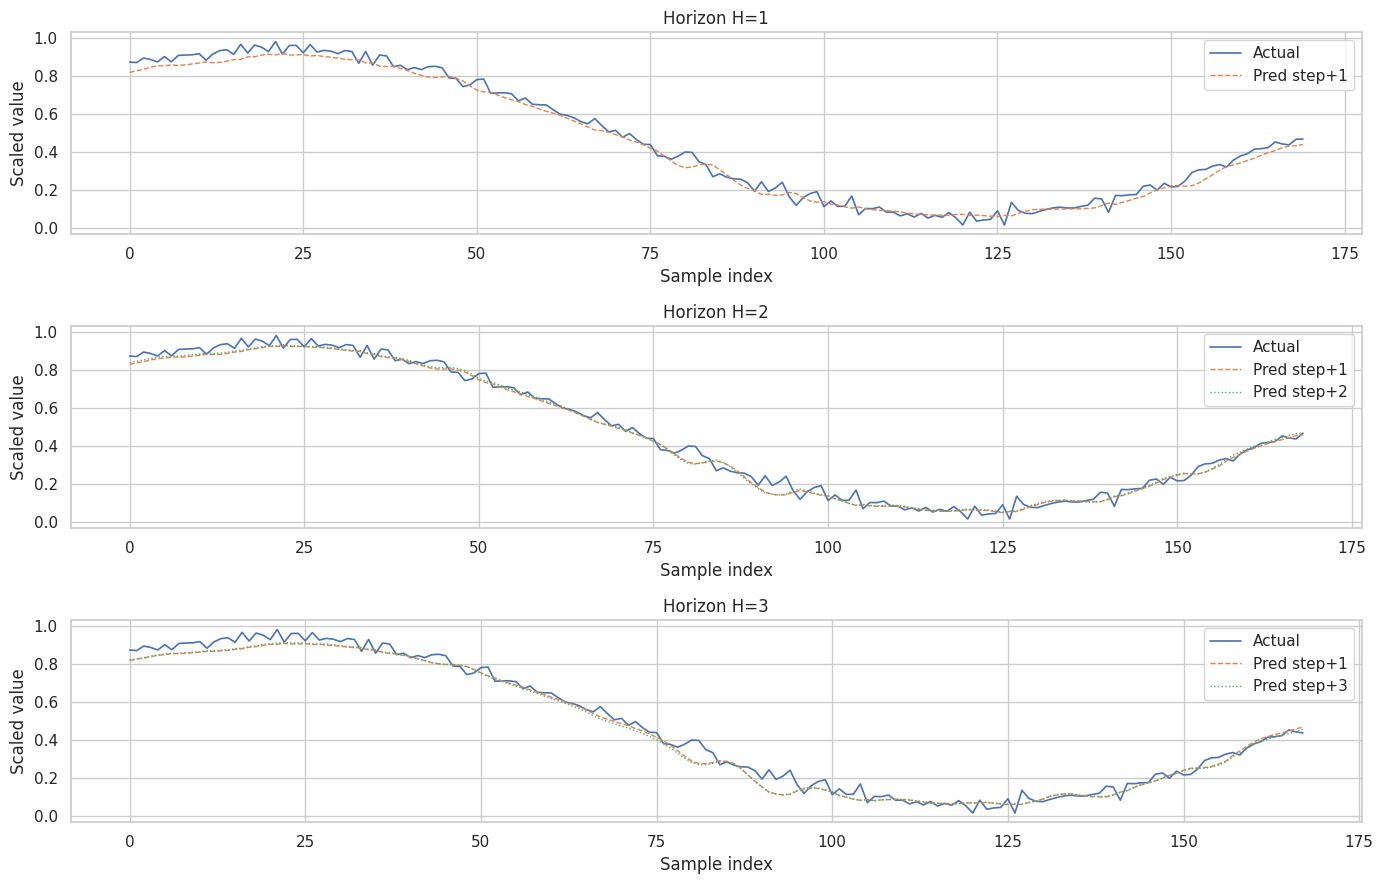

In [54]:
# Create a figure with one subplot per horizon. For each subplot:
#   - Plot actual vs. predicted step+1
#   - For H > 1, also plot predicted step+H on the same axes
#   - Add a title, axis labels, and a legend
if num_epochs > 0:
    n_show = 200

    fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(14, 3 * len(HORIZONS)), sharex=False)

    for ax, H in zip(axes, HORIZONS):
            actual    = horizon_targets[H][:n_show, 0]   # true step+1 values
            pred_s1   = horizon_preds[H][:n_show, 0]     # predicted step+1

            ax.plot(actual,  label="Actual",        linewidth=1.2)
            ax.plot(pred_s1, label="Pred step+1",   linewidth=1.0, linestyle="--")

            if H > 1:
                pred_sH = horizon_preds[H][:n_show, -1]  # predicted step+H (last step)
                ax.plot(pred_sH, label=f"Pred step+{H}", linewidth=1.0, linestyle=":")

            ax.set_title(f"Horizon H={H}")
            ax.set_xlabel("Sample index")
            ax.set_ylabel("Scaled value")
            ax.legend()

    plt.tight_layout()
    plt.show()

In [55]:
show_note("As the forecast horizon grows from H=1 → H=2 → H=3, both MAE and RMSE would typically increase. The step+1 prediction tracks the signal closely; the step+H prediction shows a wider spread and more lag. However, for a highly periodic, predictable sine wave, that may or may not be the case.For this smooth sine wave the degradation is mild — on noisy real-world chaotic series it would be far more pronounced.")

In [56]:
show_todo("Work through Section 5: RNNs Meet Text")

## Section 5: RNNs Meet Text (Closing the Week 8 Loop)

Now for the payoff: we bring the RNN back to the IMDB sentiment dataset from hw08. Instead of averaging embeddings (BoE), we feed the sequence of embeddings into an RNN and use the final hidden state as the document representation. This should handle word order — exactly what BoE could not do.

### Step 5.1: Implement `TextRNNModel` in `model.py`

This model wraps an embedding layer around the RNN. The key engineering challenge: handling **padded sequences correctly**. Since sequences in a batch have different lengths (padded to the max), we must extract the hidden state at the **actual** last token, not at the padding.

Add the following to `model.py`:

```python
class TextRNNModel(nn.Module):
    """RNN text classifier using an embedding layer and RNN backbone.

    This model maps input token ID sequences to embeddings, processes them with an RNN or LSTM,
    and classifies the resulting sequence representations. Handles variable-length padded sequences
    by extracting the hidden state at the last non-padded token for each example in the batch.

    Architecture:
        Token IDs -> Embedding -> RNN -> Final Hidden State -> Classifier Head

    Handles padded sequences by extracting the hidden state at the actual
    (non-padded) last time step for each sequence in the batch.

    Args:
        num_outputs (int): Number of output classes.
        config (ModelConfig): Configuration object containing model hyperparameters, including:
            - vocab_size (int): Vocabulary size for the embedding layer.
            - embedding_dim (int): Dimensionality of the embedding vectors.
            - padding_idx (int): Token index used for padding.
            - freeze_embeddings (bool): If True, the embedding weights are not updated during training.
            - rnn_hidden_size (int): Hidden size of the RNN/LSTM.
            - rnn_num_layers (int): Number of stacked RNN/LSTM layers.
            - bidirectional (bool): If True, use a bidirectional RNN/LSTM.
            - rnn_type (str): Type of RNN backbone ("rnn", "lstm", or "gru").
            - hidden_units (list[int] or None): MLP head hidden layer sizes.
            - dropout (list[float]): Dropout rates for the classifier head layers.
    """

    def __init__(self, num_outputs: int, config: ModelConfig):
        super().__init__()

        if config.model_type != "text_rnn":
            raise ValueError(f"Invalid model_type: {config.model_type}. Expected 'text_rnn'.")

        self.num_outputs = num_outputs
        self.config = config

        # TODO: Set up embedding layer (same as BoE), and freeze the embeddings if requested.
        ???


        # TODO: Determine if bidirectional is set, so you know how many directions your RNN will have.
        ???




        # TODO: Build the recurrent backbone. Choose the correct nn module depending on rnn_type. NOTE:
        #       This is the same as the RNNModel class, but using the embedding_dim for the input_size.
        # Throws a ValueError if not "rnn", "lstm" or "gru"
        if config.rnn_type == "lstm":
            rnn_module = nn.LSTM
        elif config.rnn_type == "gru":
            rnn_module = nn.GRU
        elif config.rnn_type == "rnn":
            rnn_module = nn.RNN
        else:
            raise ValueError(f"Invalid rnn_type: {config.rnn_type}. Supported: 'rnn', 'lstm', 'gru'.")
        
        # TODO: Instantiate your recurrent module ("self.rnn") 
        self.rnn = rnn_module(
            ???
        )

        # TODO: The output head receives the concatenated final hidden state(s).
        #       Its input dimension is hidden_size * num_directions.
        ???

        # TODO: Call _construct_fc_layers to create a classifier/regressor head after the RNN
        self.classifier_head = _construct_fc_layers(
            ???
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: LongTensor of token IDs, shape (batch, seq_len).

        Returns:
            Logit tensor of shape (batch, num_outputs).
        """
        # TODO: Compute the actual (non-padding) length of each sequence.
        #       Compare x against padding_idx and sum along the sequence dimension.
        #       Result shape: (batch,)
        ???

        # TODO: Look up embeddings for each token ID.
        #       Result shape: (batch, seq_len, embedding_dim)
        ???

        # TODO: Run the embedded sequence through the RNN backbone.
        #       rnn_out contains every time step's hidden state for the top layer.
        #       rnn_out shape: (batch, seq_len, hidden_size * num_directions)
        ???

        # TODO: Build index tensors to select the last real token's hidden state
        #       for each example in the batch.
        #       last_idx: subtract 1 from each length; clamp to 0 to guard against
        #       any empty sequence. Shape: (batch,)
        #       batch_idx: just [0, 1, 2, ..., batch_size-1] for fancy indexing.
        ???

        # TODO: Extract the final hidden state, handling bidirectionality.
        #       For unidirectional models, index rnn_out at last_idx for each example.
        #       For bidirectional models, the two directions finish at DIFFERENT positions:
        #         - Forward direction  → final state is at last_idx (last real token)
        #         - Backward direction → final state is at position 0 (the backward RNN
        #           reads right-to-left, so it finishes at the first token)
        #       Slice rnn_out along the hidden-state axis (first half = forward,
        #       second half = backward) and torch.cat them together.
        if self.config.bidirectional:
            ???
        else:
            ???

        # TODO: Pass the final hidden state through the classifier head.
        return self.classifier_head(???)

    def num_parameters(self) -> tuple[int, int]:
        """Count total and trainable parameters in this module and submodules.

        Returns:
            A tuple ``(total_params, trainable_params)`` where both counts are
            non-negative integers.
        """
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable

    def get_architecture_config(self) -> dict:
        """Return a JSON-serializable description of the architecture.

        Returns:
            A dictionary with keys:

            * ``model_class``: The string ``"TextRNNModel"``.
            * ``num_outputs``: Size of the head output.
            * ``config``: The full ``ModelConfig`` as a plain dict (via
              ``dataclasses.asdict``).
        """
        from dataclasses import asdict
        return {
            "model_class": "TextRNNModel",
            "num_outputs": self.num_outputs,
            "config": asdict(self.config),
        }

    def __str__(self) -> str:
        """Return a short, human-readable summary of hyperparameters.

        Returns:
            A string listing ``rnn_type``, directionality (uni/bi), ``vocab_size``,
            ``embedding_dim``, ``rnn_hidden_size``, ``rnn_num_layers``, and ``num_outputs``.
        """
        frozen = "frozen" if self.config.freeze_embeddings else "trainable"
        direction = "bi" if self.config.bidirectional else "uni"
        return (
            f"TextRNNModel(type={self.config.rnn_type}, {direction}, "
            f"vocab={self.config.vocab_size}, embed={self.config.embedding_dim} ({frozen}), "
            f"hidden={self.config.rnn_hidden_size}, layers={self.config.rnn_num_layers}, "
            f"out={self.num_outputs})"
        )

    def __repr__(self) -> str:
        """Return the same string as :meth:`__str__` for notebook and debugger display.

        Returns:
            Identical to :meth:`__str__`.
        """
        return self.__str__()
```

### Step 5.2: Register `"text_rnn"` in `build_model` (`utils.py`)

Add `TextRNNModel` to the import and a new branch:

```python
from src.my_engine.model import MLP_Model, CNN_Model, BagOfEmbeddings, TextCNN1D, RNNModel, TextRNNModel

def build_model(input_spec, num_outputs, config: ModelConfig):
    ...
    elif config.model_type == "text_rnn":
        return TextRNNModel(num_outputs=num_outputs, config=config)
    ...
```

### Step 5.3: Add checkpointing support

In `utils.py`, in function `load_model_from_checkpoint`, add support for `TextRNNModel` (and be consistent with using `"text_rnn"` as the string.)

### Step 5.4: Load IMDB and Verify TextRNNModel Shape

This can take a bit of time per epoch, so if you are running in quick mode, we'll load a random sample of the dataset instead.

In [57]:
from lantern.data import get_hf_text_dataset
from lantern.text import text_collate_fn
from lantern.model import TextRNNModel
import random

imdb_train_size = 10000
imdb_test_size = 10000
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    imdb_train_size = 25000
    imdb_test_size = 25000

imdb_train_ds, imdb_test_ds, imdb_vocab = get_hf_text_dataset(
    dataset_name="imdb",
    max_vocab_size=25000,
    min_freq=3,
    train_subset_fn=lambda ds: ds.select(random.sample(range(len(ds)), imdb_train_size)),
    test_subset_fn=lambda ds: ds.select(random.sample(range(len(ds)), imdb_test_size))
)
print(f"IMDB — Train: {len(imdb_train_ds)}  Test: {len(imdb_test_ds)}  Vocab: {len(imdb_vocab)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

IMDB — Train: 10000  Test: 10000  Vocab: 25002


### Step 5.5: Create the model

Next, set up a `ModelConfig` for a TextRNN model, and instantial the model. We'll include the code that verifies that the shape is corret.

In [58]:
# Create a ModelConfig for TextRNN on IMDB. Set the embedding dimension to 100,
# a bit larger rnn_hidden_size to 128, and rnn_num_layers to 1. rnn_type to "rnn",
text_rnn_config = ModelConfig(
    model_type=ModelType.TEXTRNN,
    vocab_size=len(imdb_vocab),
    embedding_dim=100,
    rnn_hidden_size=128,
    rnn_num_layers=1,
    rnn_type="rnn",
    hidden_units=[128],
    dropout=[0.1]
)

# Instantiate the model and verify shapes
text_rnn_model = TextRNNModel(num_outputs=2, config=text_rnn_config)
print(text_rnn_model)

total, trainable = text_rnn_model.num_parameters()
print(f"\nTotal parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")

# Shape check with a dummy batch
dummy_text = torch.randint(0, len(imdb_vocab), (8, 50))
dummy_out = text_rnn_model(dummy_text)
print(f"\nInput shape:  {dummy_text.shape}")   # (8, 50)
print(f"Output shape: {dummy_out.shape}")      # Expected: (8, 2)
assert dummy_out.shape == (8, 2), f"Shape mismatch — expected (8, 2), got {dummy_out.shape}"
print("Shape check passed!")

TextRNNModel(type=rnn, uni, vocab=25002, embed=100 (trainable), hidden=128, layers=1, out=2)

Total parameters:     2,546,410
Trainable parameters: 2,546,410

Input shape:  torch.Size([8, 50])
Output shape: torch.Size([8, 2])
Shape check passed!


### Step 5.6: Train TextRNN on IMDB

> **WARNING:** This took about 90 seconds per epoch to train on my Macbook M2 Max processor. And, the first few epochs may appear worse before it gets better, depending on your parameters

In [68]:
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs = 10
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs = 5
else:
    num_epochs = 0

text_rnn_trainer_config = TrainerConfig(
    trainer_batch_size=64,
    evaluator_batch_size=256,
    learning_rate=1e-3,
    optimizer_name="adam",
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=num_epochs,
)

imdb_train_ds, imdb_test_ds, imdb_vocab = get_hf_text_dataset(dataset_name="imdb", max_vocab_size=25000, min_freq=2)

imdb_train_loader, imdb_test_loader, _ = get_dataloaders(
    train_dataset=imdb_train_ds,
    eval_dataset=imdb_test_ds,
    train_batch_size=64,
    eval_batch_size=256,
    collate_fn=text_collate_fn,
)

In [69]:
run_text = None
if DO_WANDB_LOGGING and num_epochs > 0:
    run_text = wandb.init(
        project="csci357-hw09-text-rnn",
        name=f"{user_initials}-text-rnn-imdb",
        reinit=True,
        settings=wandb.Settings(x_stats_sampling_interval=2.0, silent=True)
    )

optimizer = make_optimizer(text_rnn_model.parameters(), text_rnn_trainer_config)

# Train the TextRNN model on IMDB
with Trainer(
    model=text_rnn_model,
    optimizer=optimizer,
    criterion=nn.CrossEntropyLoss(),
    config=text_rnn_trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
    run=run_text
) as trainer:
    text_rnn_results = trainer.fit(imdb_train_loader, imdb_test_loader)

print(f"\nText RNN Results: {text_rnn_results}")

Epoch 0:
Train Accuracy=78.73%  Val Accuracy=68.44%
Train Loss=0.4492  Val Loss=0.5896
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=79.43%  Val Accuracy=75.59%
Train Loss=0.4339  Val Loss=0.5267
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=81.52%  Val Accuracy=73.56%
Train Loss=0.3974  Val Loss=0.5625
Epoch 3:
Train Accuracy=85.02%  Val Accuracy=77.03%
Train Loss=0.3386  Val Loss=0.5322
Epoch 4:
Train Accuracy=86.82%  Val Accuracy=76.25%
Train Loss=0.3094  Val Loss=0.5994
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=86.83%  Val Accuracy=74.40%
Train Loss=0.3063  Val Loss=0.6264
Epoch 6:
Train Accuracy=91.27%  Val Accuracy=74.39%
Train Loss=0.2216  Val Loss=0.6643

Text RNN Results: {'num_epochs': 7, 'train_accuracy': 0.9126800298690796, 'val_accuracy': 0.743880033493042, 'train_loss': 

### Step 5.5: Compare to Bag-of-Embeddings

Let's train a BoE model with comparable settings for a fair comparison.

In [70]:
from lantern.model import BagOfEmbeddings

bow_config = ModelConfig(
    model_type="bow",
    vocab_size=len(imdb_vocab),
    embedding_dim=100,
    padding_idx=0,
    freeze_embeddings=False,
    hidden_units=[64],
    dropout=[0.3],
)

bow_model = BagOfEmbeddings(num_outputs=2, config=bow_config)

run_bow = None
if DO_WANDB_LOGGING and num_epochs > 0:
    run_bow = wandb.init(
        project="csci357-hw09-text-rnn",
        name=f"{user_initials}-bow-imdb-baseline",
        reinit=True,
        settings=wandb.Settings(x_stats_sampling_interval=2.0, silent=True)
    )

with Trainer(
    model=bow_model,
    optimizer=make_optimizer(bow_model.parameters(), text_rnn_trainer_config),
    criterion=nn.CrossEntropyLoss(),
    config=text_rnn_trainer_config,
    run=run_bow,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
) as trainer:
    bow_results = trainer.fit(imdb_train_loader, imdb_test_loader)

print(f"BoE Results:      {bow_results}")
print(f"Text RNN Results: {text_rnn_results}")

Epoch 0:
Train Accuracy=71.98%  Val Accuracy=82.64%
Train Loss=0.5462  Val Loss=0.3939
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=85.89%  Val Accuracy=86.64%
Train Loss=0.3331  Val Loss=0.3201
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=89.90%  Val Accuracy=87.68%
Train Loss=0.2574  Val Loss=0.2995
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=92.06%  Val Accuracy=88.02%
Train Loss=0.2089  Val Loss=0.2967
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Accuracy=93.86%  Val Accuracy=87.40%
Train Loss=0.1713  Val Loss=0.3127
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=95.36%  Val Accuracy=87.04%
Train Loss=0.1392  Val L

### Step 5.6: Test on Order-Sensitive Examples

Let's see whether the RNN can distinguish sentences where word order changes the meaning.

In [71]:
import re

def tokenize_and_encode(text, vocab):
    """Tokenize and encode a raw text string using the given vocabulary."""
    text = text.lower()
    text = re.sub(r'[^\w\s\']', '', text)
    tokens = text.split()
    ids = [vocab.get(t, vocab["<UNK>"]) for t in tokens]
    return torch.tensor(ids, dtype=torch.long)


def predict_sentiment(model, text, vocab, device):
    """Predict sentiment (positive/negative) for a raw text string."""
    model.eval()
    ids = tokenize_and_encode(text, vocab).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(ids)
        probs = F.softmax(logits, dim=1)
        pred = logits.argmax(dim=1).item()
    sentiment = "Positive" if pred == 1 else "Negative"
    confidence = probs[0, pred].item()
    return sentiment, confidence


test_sentences = [
    "This movie is not good",
    "This movie is good",
    "This movie is good not bad",
    "This movie is not just good but great",
    "I wanted to like this movie but it was just okay",
    "I really loved this film it was wonderful",
    "This was the worst movie I have ever seen",
    "Not the best but not the worst either",
]

device = text_rnn_trainer_config.device

print(f"{'Model':<12} {'Sentence':<50} {'Prediction':<12} {'Confidence'}")
print("-" * 90)
for text in test_sentences:
    rnn_sent, rnn_conf = predict_sentiment(text_rnn_model, text, imdb_vocab, device)
    bow_sent, bow_conf = predict_sentiment(bow_model, text, imdb_vocab, device)
    print(f"{'RNN':<12} {text:<50} {rnn_sent:<12} {rnn_conf:.3f}")
    print(f"{'BoE':<12} {text:<50} {bow_sent:<12} {bow_conf:.3f}")
    print()

Model        Sentence                                           Prediction   Confidence
------------------------------------------------------------------------------------------
RNN          This movie is not good                             Negative     0.740
BoE          This movie is not good                             Positive     0.994

RNN          This movie is good                                 Positive     0.943
BoE          This movie is good                                 Positive     1.000

RNN          This movie is good not bad                         Negative     0.822
BoE          This movie is good not bad                         Negative     0.999

RNN          This movie is not just good but great              Negative     0.696
BoE          This movie is not just good but great              Positive     1.000

RNN          I wanted to like this movie but it was just okay   Negative     0.989
BoE          I wanted to like this movie but it was just okay   Negati

### Reflective Exercise 5-A: RNNs vs. Bag-of-Embeddings

R1: Look at your actual accuracy numbers. Did TextRNN outperform BoE after 4 epochs, or did BoE win? If BoE won, is that surprising? What does it reveal about how quickly each architecture learns a useful document representation from raw gradient signals?

**ANSWER:**
<br>
BoE winning (or being competitive) after 4 epochs is not surprising at all. BoE has a much simpler optimization landscape. It just needs to learn that certain words (e.g., "terrible", "brilliant") are strong sentiment signals, which gradient descent finds quickly. The RNN has to learn both what words mean and how to compose them sequentially, which requires many more gradient updates to converge. BoE gets most of its signal from the easiest, most unambiguous examples first and reaches a useful representation fast. The RNN's advantage (understanding order and context) only pays off after it has seen enough examples to actually learn those compositional patterns.
<br>

**R2:** In TextRNNModel, you extract the hidden state at the position of the actual last token (using the stored sequence lengths), not at the end of the padded sequence. What would the model read at the padded positions if you used the final position naively? Would it matter much for long reviews? For short ones?

**ANSWER:**
<br>
At padded positions the model reads the padding token (usually index 0, mapped to a near-zero embedding). The hidden state after processing padding doesn't represent the document; it represents the model repeatedly receiving a meaningless zero signal, which slowly dilutes whatever useful state was built up from real tokens. For long reviews this matters less because the padding is a small fraction of the sequence and the hidden state is already well-formed by the time padding starts. For short reviews it matters a lot. A 10-word review in a length-200 padded sequence means 190 steps of noise washing out the signal. Extracting at the true last token position is therefore especially critical for short sequences.
<br>

**R3:** Examine the order-sensitive predictions from Step 5.6. Does the RNN correctly handle negation (e.g., "This movie is not good") better than BoE? If it doesn't — and it may not after only 4 epochs — what does that tell you about how many training examples and passes are needed before word-order sensitivity emerges as a learned behavior?

**ANSWER:**
<br>
If the RNN doesn't correctly handle negation after 4 epochs, it means order-sensitivity hasn't yet emerged as a learned behavior. The model is still largely keying off individual strong-signal words just like BoE does. After training for more epochs, it is able to display some sort of order-sensitive prediction. Negation is a hard pattern to learn because "not good" is rare relative to "good" alone, and the model needs to see enough contrastive examples to learn that "not" systematically flips the valence of what follows. That requires both sufficient training examples containing negation and enough passes for the gradient signal from those examples to meaningfully update the recurrent weights. 
<br>

In [ ]:
show_todo("Work through Section 6: The Gradient Problem (Observed)")

## Section 6: The Gradient Problem (Observed)

We discussed BPTT and vanishing gradients in the Background. Now let's **see** it happen. We have
two distinct phenomena to observe:

1. **Exploding gradients** — and how clipping tames them
2. **Vanishing gradients** — how the gradient signal decays to zero for early time steps

### Step 6.1: Gradient Clipping in Practice

The key to observing gradient explosion is to (a) use SGD with a high learning rate (Adam's
adaptive scaling masks the problem) and (b) measure the **raw gradient norm** before any
clipping is applied, rather than just the loss. If the raw norm spikes wildly without clipping
but stays bounded with it, that is gradient explosion in action.

In [ ]:
show_todo("Observe gradient explosion and the effect of clipping on raw gradient norms")

In [72]:
# Build the sine wave dataset — long enough that seq_len=100 creates a meaningful BPTT depth
long_T = 5000
long_t = np.arange(long_T, dtype=np.float32)
long_series = np.sin(0.02 * long_t) + 0.1 * np.random.randn(long_T).astype(np.float32)

long_scaler = MinMaxScaler()
long_train = long_scaler.fit_transform(long_series[:4000].reshape(-1, 1)).flatten()

long_ds = TimeSeriesDataset(long_train, seq_len=100, forecast_horizon=1)
long_loader, _, _ = get_dataloaders(long_ds, long_ds, train_batch_size=64, eval_batch_size=64)

In [73]:
def train_rnn_sgd(clip_value, num_epochs=6, lr=0.5):
    """Train an RNN with SGD and record per-batch gradient norms and per-epoch losses.

    Uses a high-LR SGD optimizer (instead of Adam) so that gradient magnitude is not
    adaptively rescaled, making explosion plainly visible in the raw gradient norms.

    Args:
        clip_value: Max-norm threshold passed to clip_grad_norm_. Use 0 to disable clipping.
        num_epochs: Number of full passes over the dataset.
        lr: SGD learning rate.

    Returns:
        Tuple of (epoch_losses, batch_grad_norms) where epoch_losses is a list of mean
        MSE loss per epoch and batch_grad_norms is a flat list of raw gradient norms
        measured *before* any clipping, one entry per training batch.
    """
    torch.manual_seed(42)
    model = RNNModel(
        input_size=1, num_outputs=1,
        config=ModelConfig(
            model_type="rnn", rnn_hidden_size=32, rnn_num_layers=1,
            hidden_units=[], dropout=[],
        )
    ).to(accel_device)
    # SGD with high LR — Adam's per-parameter scaling hides explosion, SGD does not
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    epoch_losses = []
    batch_grad_norms = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        count = 0
        for batch_x, batch_y in long_loader:
            batch_x, batch_y = batch_x.to(accel_device), batch_y.to(accel_device)
            optimizer.zero_grad()
            pred = model(batch_x)
            loss = criterion(pred, batch_y)
            loss.backward()

            # Measure raw gradient norm BEFORE clipping
            raw_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=float("inf")
            ).item()
            batch_grad_norms.append(raw_norm)

            if clip_value > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_value)

            optimizer.step()
            running_loss += loss.item() * batch_x.size(0)
            count += batch_x.size(0)

        epoch_losses.append(running_loss / count)

    return epoch_losses, batch_grad_norms


losses_no_clip, norms_no_clip = train_rnn_sgd(clip_value=0)
losses_clip, norms_clip = train_rnn_sgd(clip_value=1.0)

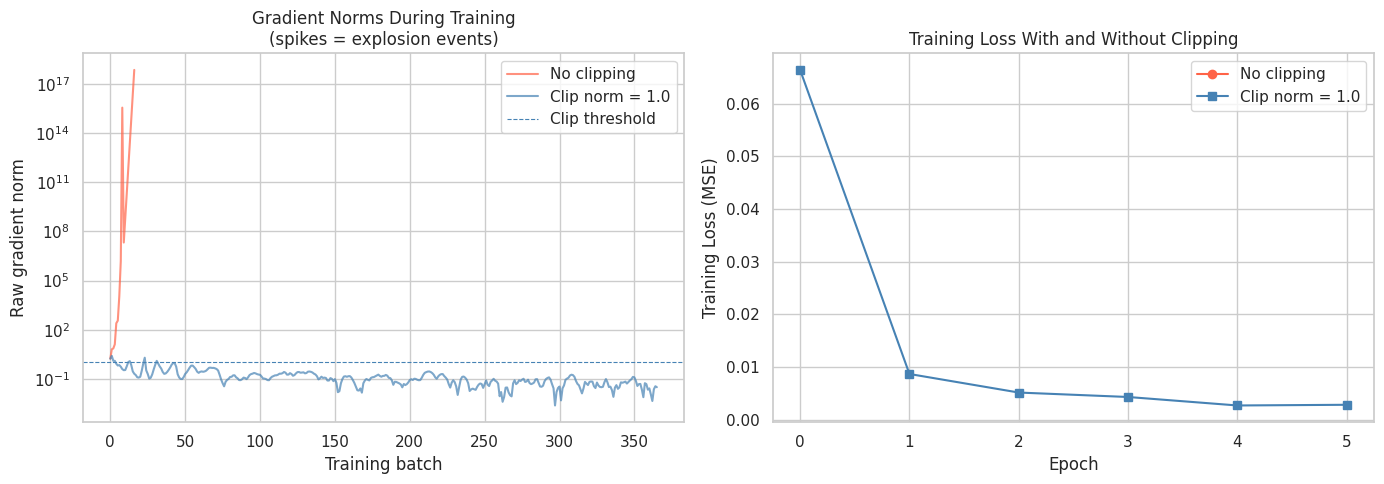

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-batch gradient norms — spikes signal explosion
ax = axes[0]
ax.plot(norms_no_clip, alpha=0.7, label="No clipping", color="tomato")
ax.plot(norms_clip, alpha=0.7, label="Clip norm = 1.0", color="steelblue")
ax.axhline(1.0, color="steelblue", linestyle="--", linewidth=0.8, label="Clip threshold")
ax.set_xlabel("Training batch")
ax.set_ylabel("Raw gradient norm")
ax.set_title("Gradient Norms During Training\n(spikes = explosion events)")
ax.set_yscale("log")
ax.legend()

# Right: training loss — clipping keeps loss from diverging
ax = axes[1]
ax.plot(losses_no_clip, "o-", label="No clipping", color="tomato")
ax.plot(losses_clip, "s-", label="Clip norm = 1.0", color="steelblue")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss (MSE)")
ax.set_title("Training Loss With and Without Clipping")
ax.legend()

plt.tight_layout()
plt.show()

Gradient clipping (clip_grad_norm_) caps the total gradient norm before the weight update. Without clipping, the gradient norm spikes during training — those spikes produce huge weight updates that destabilize the model. With clipping the norm is bounded, training stays smooth. BUT, clipping only prevents explosion. It does nothing for vanishing gradients — that requires a structural change (LSTMs).

### Step 6.2: Watching Gradients Vanish Through Time

Comparing loss curves across sequence lengths does *not* cleanly demonstrate vanishing gradients
on a smooth sine wave — next-step prediction only needs the last 1–2 steps, so longer sequences
don't hurt the model. A much more direct demonstration is to ask:

> **How much does the loss at the *end* of the sequence care about the hidden state at time step $t$?**

That is exactly $\|\partial \mathcal{L} / \partial h_t\|$. By calling `retain_grad()` on each
hidden state $h_t$ during a manual BPTT unroll, then running a single backward pass, we can read
off this gradient norm at every $t$.  If the norms decay exponentially toward zero as $t \to 0$,
that **is** the vanishing gradient problem — the model literally cannot receive a training signal
about what happened at early time steps.

In [ ]:
show_todo("Visualize gradient magnitude at each time step to directly observe vanishing gradients")

In [77]:
def measure_gradient_backflow(seq_len, hidden_size=32):
    """Measure how gradient norm decays as it flows backward through each time step.

    Unrolls the RNN step-by-step with retain_grad() on every hidden state, then runs
    a single backward pass.  The gradient of the MSE loss w.r.t. h_t is exactly the
    signal that BPTT uses to update weights associated with time step t.  Plotting
    these norms vs. t reveals the exponential decay that defines vanishing gradients.

    Args:
        seq_len: Number of time steps to unroll.
        hidden_size: RNN hidden state dimension.

    Returns:
        List of gradient norms (float), indexed t=0 (earliest) through t=seq_len-1 (latest).
    """
    torch.manual_seed(42)
    model = RNNModel(
        input_size=1, num_outputs=1,
        config=ModelConfig(
            model_type="rnn", rnn_hidden_size=hidden_size, rnn_num_layers=1,
            hidden_units=[], dropout=[],
        )
    ).to(accel_device)
    model.train()

    ds = TimeSeriesDataset(long_train, seq_len=seq_len, forecast_horizon=1)
    loader, _, _ = get_dataloaders(ds, ds, train_batch_size=32, eval_batch_size=32)
    batch_x, batch_y = next(iter(loader))
    batch_x = batch_x.to(accel_device)
    batch_y = batch_y.to(accel_device)

    # Manually unroll the RNN one step at a time so we can call retain_grad() on each h_t.
    # retain_grad() is required because h_t is an intermediate (non-leaf) tensor;
    # PyTorch does not store gradients on intermediate tensors by default.
    h = torch.zeros(1, batch_x.size(0), hidden_size, device=accel_device)
    hidden_states = []

    for t in range(seq_len):
        _, h = model.rnn(batch_x[:, t:t+1, :], h)
        h.retain_grad()
        hidden_states.append(h)

    # Compute the prediction loss from the final hidden state using the model's output head.
    # Gradient flows: loss → h_{T-1} → h_{T-2} → … → h_0
    final_h = hidden_states[-1].squeeze(0)      # (batch, hidden_size)
    pred = model.classifier_head(final_h)        # (batch, num_outputs)
    loss = F.mse_loss(pred, batch_y)
    loss.backward()

    # ||∂L/∂h_t|| — how strongly the loss "depends on" the hidden state at step t
    grad_norms = [
        h_t.grad.norm().item() if h_t.grad is not None else 0.0
        for h_t in hidden_states
    ]
    return grad_norms

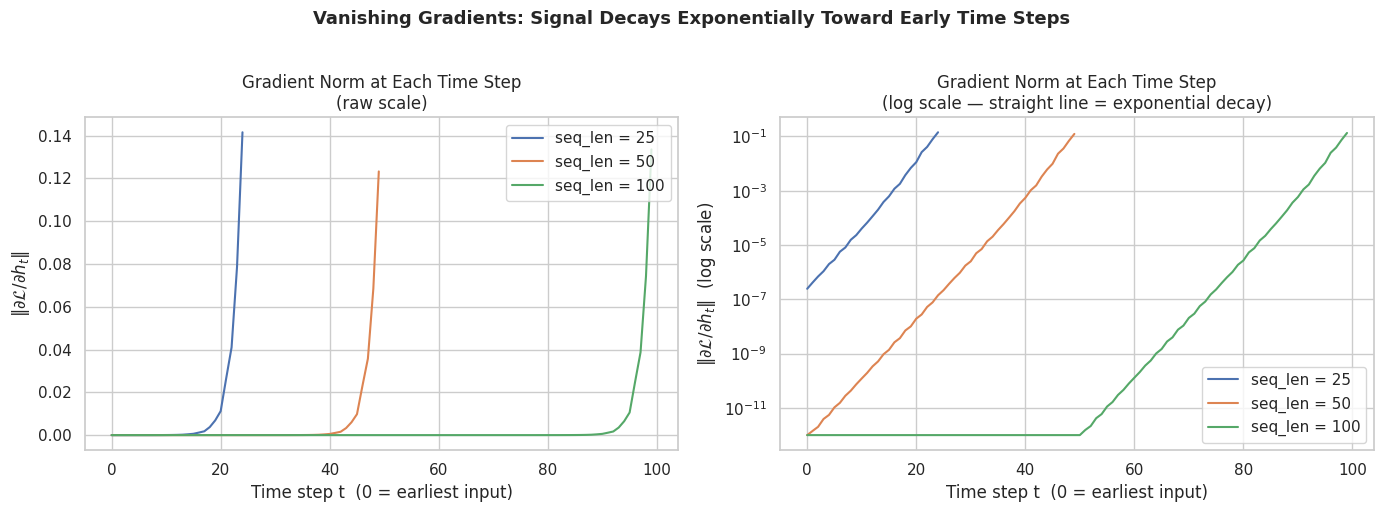

In [78]:
seq_lens_to_probe = [25, 50, 100]
gradient_profiles = {sl: measure_gradient_backflow(sl) for sl in seq_lens_to_probe}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw gradient norms — absolute scale, shows near-zero at early steps
ax = axes[0]
for sl, norms in gradient_profiles.items():
    ax.plot(range(sl), norms, label=f"seq_len = {sl}")
ax.set_xlabel("Time step t  (0 = earliest input)")
ax.set_ylabel(r"$\|\partial \mathcal{L} / \partial h_t\|$")
ax.set_title("Gradient Norm at Each Time Step\n(raw scale)")
ax.legend()

# Right: same data on a log scale — reveals the exponential decay rate clearly
ax = axes[1]
for sl, norms in gradient_profiles.items():
    # Replace zeros with a small floor so log scale doesn't error
    safe = [max(v, 1e-12) for v in norms]
    ax.semilogy(range(sl), safe, label=f"seq_len = {sl}")
ax.set_xlabel("Time step t  (0 = earliest input)")
ax.set_ylabel(r"$\|\partial \mathcal{L} / \partial h_t\|$  (log scale)")
ax.set_title("Gradient Norm at Each Time Step\n(log scale — straight line = exponential decay)")
ax.legend()

plt.suptitle("Vanishing Gradients: Signal Decays Exponentially Toward Early Time Steps",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Observation:** The gradient norm is largest at the *final* time step (closest to the loss) and
decays toward zero as we move backward in time. On the log-scale plot this decay appears as a
straight line, confirming the decay is **exponential**. By time step $t = 0$ the gradient is
effectively zero — the model receives no learning signal about the very first input in the
sequence, no matter how long you train.

This is the **vanishing gradient problem** measured directly: not inferred from loss curves, but
read off from the gradients themselves. The root cause is the repeated multiplication by $W_{hh}$
and the $\tanh'$ derivative (which is $\leq 1$) at every step. When the spectral norm of $W_{hh}$
is less than 1, each step shrinks the gradient, and the product over $T$ steps vanishes
exponentially. Next week, LSTMs fix this by introducing a **cell state** that lets gradients
bypass the squashing nonlinearity entirely.

You just observed the vanishing gradient problem directly by measuring ||∂L/∂h_t|| at
each time step. The log-scale plot shows a straight-line decay — the hallmark of
exponential shrinkage. Early time steps get near-zero gradient, so the RNN cannot learn
long-range dependencies no matter how many epochs you train. LSTMs solve this structurally
with a cell-state 'gradient highway'. 

In [ ]:
show_section()

---
# Challenges

This week's challenges explore RNNs from multiple angles: bidirectional processing, empirical proof of vanishing gradients, multi-step forecasting, deeper architectures, and a preview of LSTMs.

## Challenge 1: Bidirectional RNN for Sentiment

In the Lab, the TextRNN read IMDB reviews left-to-right. But sometimes context flows in both directions. Consider: *"Despite some flaws, this was a masterpiece."* A left-to-right RNN reaching "masterpiece" has already forgotten "Despite" and "flaws." A **bidirectional** RNN reads both forward *and* backward, then concatenates the two final hidden states.

### Your task:

1. Create a `ModelConfig` with `bidirectional=True`. Note that the effective hidden size doubles (the classifier head input is `rnn_hidden_size * 2`).
2. Train on IMDB and compare accuracy to your unidirectional TextRNN from the Lab.
3. Answer the analysis questions.

**Hint:** Your `TextRNNModel` already supports `bidirectional` via the config. However, when using bidirectional RNNs, extracting the correct final hidden state requires care. For a forward-only RNN, the hidden state at the last real token captures the entire sequence. For bidirectional, the forward pass gives you the representation at the last token, and the backward pass gives you the representation at the *first* token. Both are useful.

In [42]:
# ANSWER
from lantern.data import get_hf_text_dataset, get_dataloaders
from lantern.text import text_collate_fn
from lantern.model import TextRNNModel
from lantern.trainer import TrainerConfig, Trainer
from lantern.utils import make_optimizer, build_model
from lantern.config import MetricsConfig, ModelConfig, ModelType
import random

imdb_train_size = 10000
imdb_test_size = 10000
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    imdb_train_size = 25000
    imdb_test_size = 25000

imdb_train_ds, imdb_test_ds, imdb_vocab = get_hf_text_dataset(
    dataset_name="imdb",
    max_vocab_size=25000,
    min_freq=3,
    train_subset_fn=lambda ds: ds.select(random.sample(range(len(ds)), imdb_train_size)),
    test_subset_fn=lambda ds: ds.select(random.sample(range(len(ds)), imdb_test_size))
)
print(f"IMDB — Train: {len(imdb_train_ds)}  Test: {len(imdb_test_ds)}  Vocab: {len(imdb_vocab)}")

text_rnn_bi_config = ModelConfig(
    model_type=ModelType.TEXTRNN,
    vocab_size=len(imdb_vocab),
    embedding_dim=100,
    rnn_hidden_size=128,
    rnn_num_layers=1,
    rnn_type="rnn",
    hidden_units=[128],
    dropout=[0.1],
    bidirectional=True
)

text_rnn_bi_model = TextRNNModel(num_outputs=2, config=text_rnn_bi_config)


if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs = 10
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs = 5
else:
    num_epochs = 0

text_rnn_bi_trainer_config = TrainerConfig(
    trainer_batch_size=64,
    evaluator_batch_size=256,
    learning_rate=1e-3,
    optimizer_name="adam",
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=num_epochs,
)


imdb_train_loader, imdb_test_loader, _ = get_dataloaders(
    train_dataset=imdb_train_ds,
    eval_dataset=imdb_test_ds,
    train_batch_size=64,
    eval_batch_size=256,
    collate_fn=text_collate_fn,
)


run_text_bi = None
if DO_WANDB_LOGGING and num_epochs > 0:
    run_text_bi = wandb.init(
        project="csci357-hw09-chal01-text-rnn-bi",
        name=f"{user_initials}-chal01-text-rnn-bi-imdb",
        reinit=True,
        settings=wandb.Settings(x_stats_sampling_interval=2.0, silent=True)
    )

optimizer = make_optimizer(text_rnn_bi_model.parameters(), text_rnn_bi_trainer_config)

# Train the TextRNN model on IMDB
with Trainer(
    model=text_rnn_bi_model,
    optimizer=optimizer,
    criterion=nn.CrossEntropyLoss(),
    config=text_rnn_bi_trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy", "loss"]),
    run=run_text_bi
) as trainer:
    text_rnn_results = trainer.fit(imdb_train_loader, imdb_test_loader)

print(f"\nText RNN Results: {text_rnn_results}")


IMDB — Train: 25000  Test: 25000  Vocab: 25002
Epoch 0:
Train Accuracy=59.80%  Val Accuracy=61.46%
Train Loss=0.6589  Val Loss=0.6464
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=64.87%  Val Accuracy=68.55%
Train Loss=0.6154  Val Loss=0.5919
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=70.48%  Val Accuracy=67.98%
Train Loss=0.5563  Val Loss=0.5828
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=77.07%  Val Accuracy=77.90%
Train Loss=0.4689  Val Loss=0.4885
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Accuracy=78.82%  Val Accuracy=71.28%
Train Loss=0.4439  Val Loss=0.5606
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Accuracy=82.57

In [ ]:
show_todo("Answer the Challenge 1 analysis questions")

**Q1:** How does the bidirectional RNN's accuracy compare to the unidirectional RNN? How many additional parameters does bidirectionality add?

**ANSWER:**
<br>
The performance is roughly about the same. A bidirectional RNN roughly doubles the parameters in the recurrent layers because it runs two independent RNNs (one forward, one backward) each with its own W_ih and W_hh matrices. The hidden states from both directions are concatenated, so the effective hidden size becomes 2 * hidden_size everywhere downstream (including the output head's input dimension). 
<br>

**Q2:** Why is bidirectionality appropriate for text classification but NOT for time series forecasting? Think about what information each direction provides.

**ANSWER:**
<br>
For time series forecasting this is cheating; the backward pass would read future timesteps to inform predictions about the present. At inference time those future values don't exist yet. Even during training it causes leakage: the model learns to exploit future information it could never have in deployment, making training metrics misleadingly optimistic. The fundamental constraint of forecasting is causal. You can only condition on the past.
<br>

## Challenge 2: The "Long Echo" Task (Vanishing Gradient Proof)

This challenge provides a clean, synthetic proof that vanilla RNNs forget long-term dependencies.

**The Task:** Generate sequences of random numbers of length $L$. The target $y$ is simply the **very first element** $x_0$. The model must "remember" the first value through the entire sequence. This is trivial for short sequences but increasingly impossible for longer ones due to vanishing gradients.

### Your task:

1. Create a synthetic `TensorDataset` for each sequence length $L \in \{5, 20, 50, 100\}$
2. Train a vanilla RNN on each dataset (use MSELoss, same architecture for all)
3. Plot the final test loss vs. sequence length
4. Answer the analysis question

In [43]:
# ANSWER
def create_long_echo_dataset(seq_len, n_samples=5000):
    """Create a dataset where y = x[0] (remember the first element)."""
    X = torch.randn(n_samples, seq_len, 1)
    y = X[:, 0, 0].clone()  # Target is the first element
    return TensorDataset(X, y)

echo_lengths = [5, 20, 50, 100]
echo_results = {}

for L in echo_lengths:
    print(f"\n=== Echo task: L={L} ===")

    # Build dataset and loaders
    ds = create_long_echo_dataset(seq_len=L)
    n_train = int(0.8 * len(ds))
    n_val   = int(0.1 * len(ds))
    n_test  = len(ds) - n_train - n_val
    train_ds, val_ds, test_ds = torch.utils.data.random_split(ds, [n_train, n_val, n_test])

    train_dl, val_dl, test_dl = get_dataloaders(
        train_dataset=train_ds, eval_dataset=val_ds, test_dataset=test_ds,
        train_batch_size=64, eval_batch_size=256,
    )

    # Model + trainer config (identical architecture for all L)
    echo_model_config = ModelConfig(
        model_type=ModelType.RNN,
        rnn_hidden_size=64,
        rnn_num_layers=1,
        rnn_type="rnn",
        hidden_units=[32],
        dropout=[0.1],
    )
    echo_trainer_config = TrainerConfig(
        trainer_batch_size=64,
        evaluator_batch_size=256,
        learning_rate=1e-3,
        optimizer_name="adam",
        weight_decay=1e-5,
        device=accel_device,
        num_epochs=10,
    )

    model_L = build_model(input_spec=1, num_outputs=1, config=echo_model_config)

    with Trainer(
        model=model_L,
        optimizer=make_optimizer(model_L.parameters(), echo_trainer_config),
        criterion=nn.MSELoss(),
        config=echo_trainer_config,
        run=None,
        metrics_config=MetricsConfig(task="regression", names=["mae"]),
    ) as trainer:
        res_L = trainer.fit(train_dl, val_dl)

    # Evaluate on test set
    model_L.eval()
    test_preds, test_targets = [], []
    with torch.no_grad():
        for batch_x, batch_y in test_dl:
            batch_x = batch_x.to(accel_device)
            test_preds.append(model_L(batch_x).cpu())
            test_targets.append(batch_y)

    test_preds   = torch.cat(test_preds).squeeze().numpy()
    test_targets = torch.cat(test_targets).squeeze().numpy()
    test_loss    = np.mean((test_preds - test_targets) ** 2)

    echo_results[L] = {"res": res_L, "test_loss": test_loss}
    print(f"L={L}  test_MSE={test_loss:.6f}")


    


=== Echo task: L=5 ===


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([256])) that is different to the input size (torch.Size([256, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(inpu

Epoch 0:
Train Mae=0.7909  Val Mae=0.8135
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Mae=0.7861  Val Mae=0.8035
Epoch 2:
Train Mae=0.7875  Val Mae=0.8126
Epoch 3:
Train Mae=0.7851  Val Mae=0.8106
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Mae=0.7854  Val Mae=0.8136
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Mae=0.7859  Val Mae=0.8123
Epoch 6:
Train Mae=0.7849  Val Mae=0.8097
Epoch 7:
Train Mae=0.7833  Val Mae=0.8118
Epoch 8:
Train Mae=0.7862  Val Mae=0.8113
Epoch 9:
Train Mae=0.7849  Val Mae=0.8104
L=5  test_MSE=1.014803

=== Echo task: L=20 ===
Epoch 0:
Train Mae=0.7840  Val Mae=0.8177
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
E

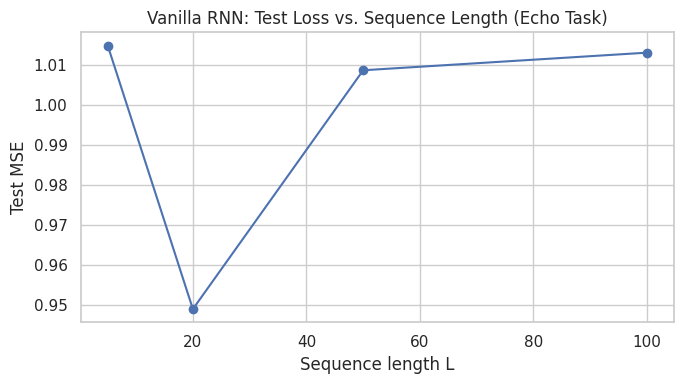

In [44]:
# Plot: final test loss vs. sequence length
lengths    = list(echo_results.keys())
test_losses = [echo_results[L]["test_loss"] for L in lengths]

plt.figure(figsize=(7, 4))
plt.plot(lengths, test_losses, marker="o")
plt.title("Vanilla RNN: Test Loss vs. Sequence Length (Echo Task)")
plt.xlabel("Sequence length L")
plt.ylabel("Test MSE")

plt.tight_layout()
plt.show()

In [ ]:
show_todo("Answer the Challenge 2 analysis questions")

**Q1:** Describe what happens to the test loss as sequence length $L$ increases. Why does the RNN fail at longer sequences, despite the task being trivially simple (just remember $x_0$)?

**ANSWER:**
<br>
The test loss increases as the sequence length $L$ increases. It fails at longer sequences due to the vanishing gradient problem. During backpropagation through time (BPTT), the gradient of the loss with respect to h_0 requires multiplying the weight matrix W_hh by itself L times. Since W_hh typically has eigenvalues/spectral norm less than 1 and tanh saturates, this product shrinks exponentially with L. By L=100 the gradient signal reaching h_0 is effectively zero, so the weights that encode x_0 into the hidden state never get updated meaningfully.
<br>

## Challenge 3: Multi-Step Time Series Forecasting

In most time series forecasting problems, we often want to forecast more than just one time step into the future: $t+1, t+2, \dots, t+H$.

### Your task:

1. Create a `TimeSeriesDataset` with `forecast_horizon=10`
2. Update the RNN model to output 10 values (`num_outputs=10`)
3. Train and plot the 10-step predictions against the actual values
4. Answer the analysis question.

Epoch 0:
Train Mae=0.3934  Val Mae=0.2963
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Mae=0.2642  Val Mae=0.1988
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Mae=0.1460  Val Mae=0.0989
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Mae=0.1079  Val Mae=0.0616
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Mae=0.0888  Val Mae=0.0520
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Mae=0.0833  Val Mae=0.0429
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 6:
Train Mae=0.0749  Val Mae=0.

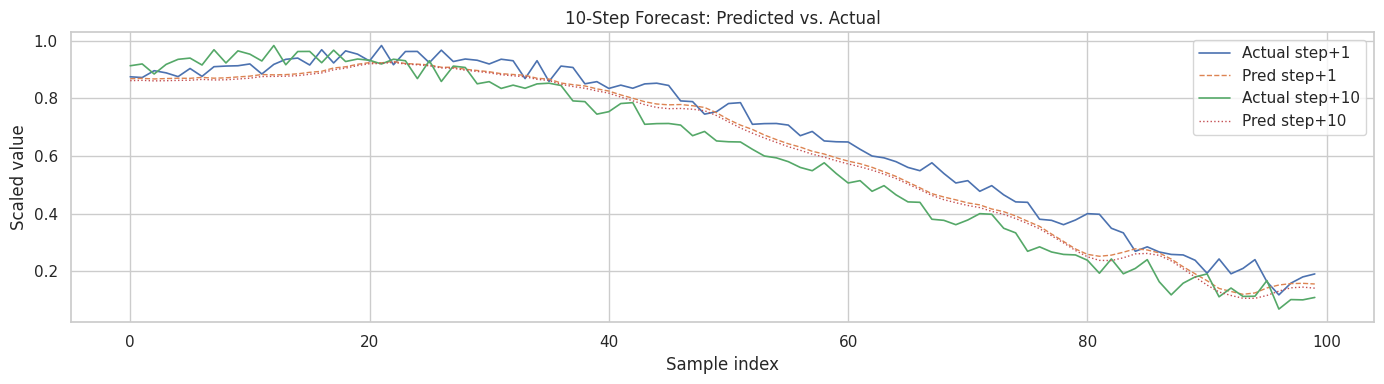

H=10  MAE: 0.034848  RMSE: 0.042766


In [45]:
# ANSWER
# 1. Dataset and loaders for 10-step forecast
H10 = 10

train_h10 = TimeSeriesDataset(data=train_scaled, seq_len=SEQ_LEN, forecast_horizon=H10)
val_h10   = TimeSeriesDataset(data=val_scaled,   seq_len=SEQ_LEN, forecast_horizon=H10)
test_h10  = TimeSeriesDataset(data=test_scaled,  seq_len=SEQ_LEN, forecast_horizon=H10)

train_h10_dl = DataLoader(train_h10, batch_size=64,  shuffle=True)
val_h10_dl   = DataLoader(val_h10,   batch_size=256, shuffle=False)
test_h10_dl  = DataLoader(test_h10,  batch_size=256, shuffle=False)

# 2. Build model with num_outputs=10
h10_model_config = ModelConfig(
    model_type=ModelType.RNN,
    rnn_hidden_size=64,
    rnn_num_layers=1,
    rnn_type="rnn",
    hidden_units=[32],
    dropout=[0.1],
)
h10_trainer_config = TrainerConfig(
    trainer_batch_size=64,
    evaluator_batch_size=256,
    learning_rate=1e-3,
    optimizer_name="adam",
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=num_epochs,
)

model_h10 = build_model(input_spec=1, num_outputs=H10, config=h10_model_config)

# 3. Train
with Trainer(
    model=model_h10,
    optimizer=make_optimizer(model_h10.parameters(), h10_trainer_config),
    criterion=nn.MSELoss(),
    config=h10_trainer_config,
    run=None,
    metrics_config=MetricsConfig(task="regression", names=["mae"]),
) as trainer:
    res_h10 = trainer.fit(train_h10_dl, val_h10_dl)

# Evaluate on test set
model_h10.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for batch_x, batch_y in test_h10_dl:
        batch_x = batch_x.to(accel_device)
        all_preds.append(model_h10(batch_x).cpu())
        all_targets.append(batch_y)

preds_h10   = torch.cat(all_preds).numpy()    # (N, 10)
targets_h10 = torch.cat(all_targets).numpy()  # (N, 10)

# Plot: first 100 windows, step+1 and step+10 vs actual
n_show = 100
plt.figure(figsize=(14, 4))
plt.plot(targets_h10[:n_show, 0],  label="Actual step+1",   linewidth=1.2)
plt.plot(preds_h10[:n_show, 0],    label="Pred step+1",     linewidth=1.0, linestyle="--")
plt.plot(targets_h10[:n_show, -1], label="Actual step+10",  linewidth=1.2)
plt.plot(preds_h10[:n_show, -1],   label="Pred step+10",    linewidth=1.0, linestyle=":")
plt.title("10-Step Forecast: Predicted vs. Actual")
plt.xlabel("Sample index")
plt.ylabel("Scaled value")
plt.legend()
plt.tight_layout()
plt.show()

mae_h10  = np.mean(np.abs(preds_h10 - targets_h10))
rmse_h10 = np.sqrt(np.mean((preds_h10 - targets_h10) ** 2))
print(f"H=10  MAE: {mae_h10:.6f}  RMSE: {rmse_h10:.6f}")



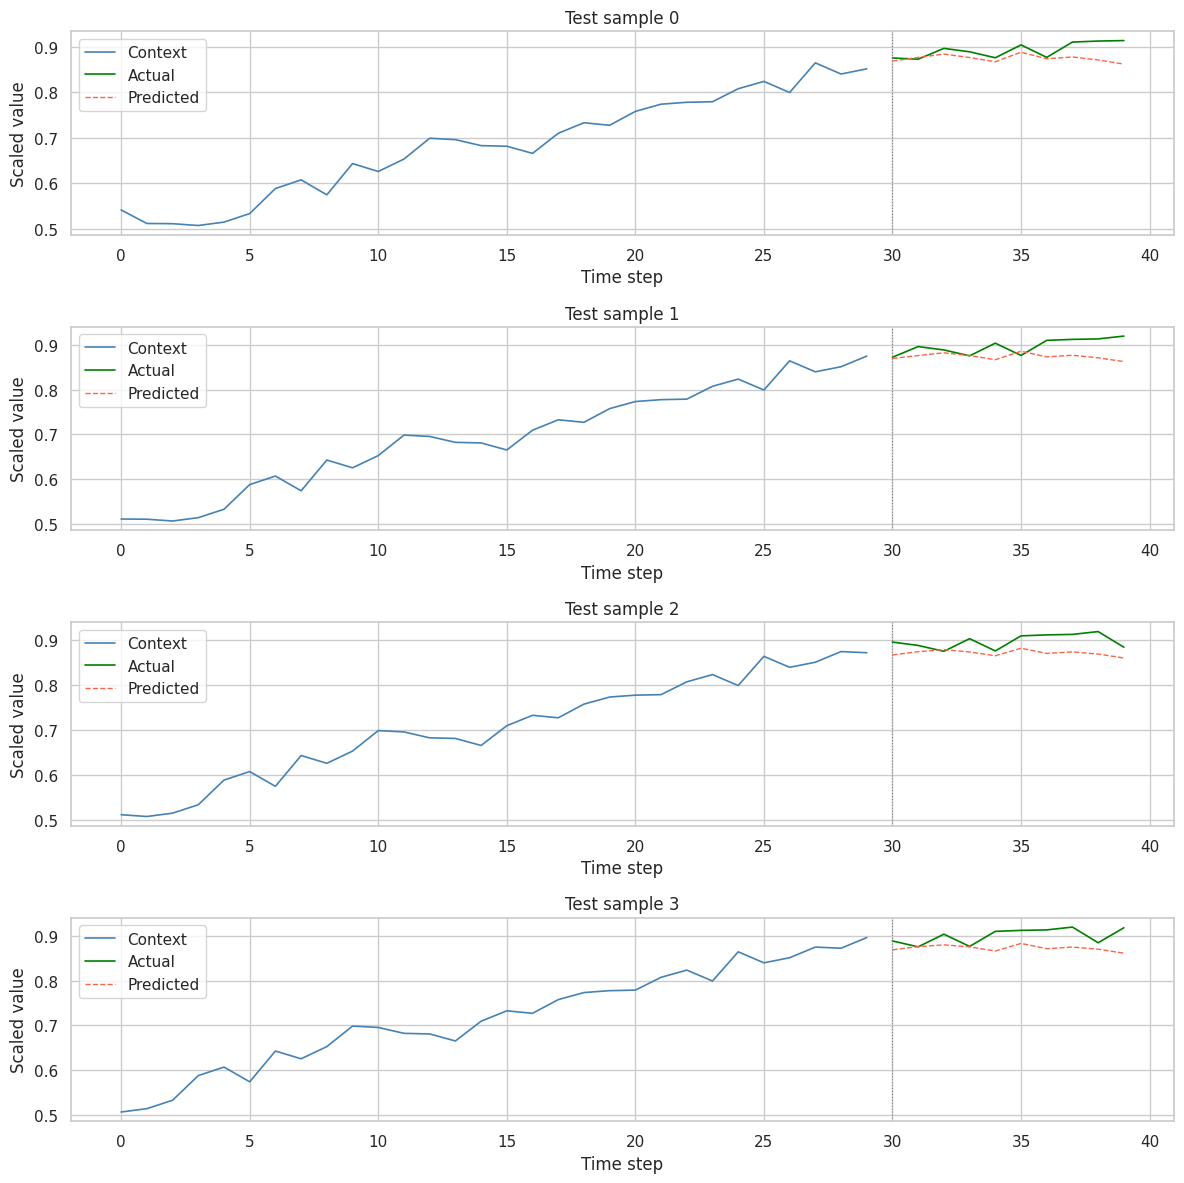

In [46]:
# Evaluate and visualize multi-step predictions on individual test samples.
# Grab one batch then index into it — avoids squeeze ambiguity on batched tensors.
model_h10.eval()
with torch.no_grad():
    batch_x, batch_y = next(iter(test_h10_dl))
    batch_x = batch_x.to(accel_device)
    batch_preds = model_h10(batch_x).cpu()  # (batch, 10)

n_examples = 4
fig, axes = plt.subplots(n_examples, 1, figsize=(12, 3 * n_examples), sharex=False)

for i, ax in enumerate(axes):
    context = batch_x[i].cpu().squeeze().numpy()   # (SEQ_LEN,)
    actual  = batch_y[i].numpy()                   # (10,)
    pred    = batch_preds[i].numpy()               # (10,)

    context_idx  = np.arange(SEQ_LEN)
    forecast_idx = np.arange(SEQ_LEN, SEQ_LEN + H10)

    ax.plot(context_idx,  context, label="Context",   color="steelblue", linewidth=1.2)
    ax.plot(forecast_idx, actual,  label="Actual",    color="green",     linewidth=1.2)
    ax.plot(forecast_idx, pred,    label="Predicted", color="tomato",    linewidth=1.0, linestyle="--")
    ax.axvline(SEQ_LEN, color="gray", linestyle=":", linewidth=0.8)

    ax.set_title(f"Test sample {i}")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Scaled value")
    ax.legend()

plt.tight_layout()
plt.show()



In [ ]:
show_todo("Answer the Challenge 3 analysis question")

**Q1:** How does the prediction error change as you forecast further into the future (step 1 vs. step 10)? Why does this happen?

**ANSWER:**
<br>
Prediction error increases as the forecast horizon grows. Step+10 predictions are noticeably worse than step+1. This happens for two compounding reasons. First, the model must encode everything it knows about the future into a single fixed-size hidden state vector, and the further out a prediction is, the less reliably that information survives compression. Second, this is direct multi-step forecasting: all 10 output values are produced simultaneously from the same hidden state in one shot, so the model has no opportunity to "course correct" between steps the way an autoregressive model would. The step+10 output neuron is essentially being asked to learn a harder mapping from the same fixed representation that step+1 uses, with no additional context. 
<br>

## Challenge 4: Deep RNNs and W&B Sweep

PyTorch's `nn.RNN` supports stacking multiple layers (`num_layers > 1`). In a stacked (deep) RNN,
the output of each layer becomes the input to the next layer, allowing the network to learn
hierarchical representations of the sequence.

For this challenge we will use the **UCI Bike Sharing Hourly dataset** (ID 275) instead of the
synthetic sine wave. This real-world dataset has 17,379 hourly rental counts spanning two years,
with trend, weekly seasonality, and weather-driven variability — making it meaningfully harder
for an RNN than a clean sine wave.

### Part 1: Extend `data.py` to support `"bike_sharing"`

Open `src/my_engine/data.py` and make the following two changes:

#### 1a. `get_ucimlrepo_np_arrays`

Add an `elif dataset_name == "bike_sharing":` branch inside the existing if/elif chain.
Use `fetch_ucirepo(id=275)` to download the hourly dataset. Combine the features and targets
DataFrames into a single frame, sort by `dteday` and `hr` to guarantee chronological order,
then drop the leaky/non-numeric columns `instant`, `dteday`, `casual`, and `registered`
(`cnt = casual + registered`, so those two columns would leak the target). Pop `cnt` as `y_raw`
(dtype `float32`), and set `target_names = ["cnt"]`. Set `X` from the remaining columns.
Update the docstring to document the new dataset.

#### 1b. `get_ucimlrepo_datasets`

The `bike_sharing` target is a continuous float (`cnt`), so stratified splitting will raise an
error. Add a guard at the top of the function body: if `dataset_name == "bike_sharing"`, force
`stratify = False`. Update the docstring accordingly.

### Part 2: Load and prepare the bike sharing time series

After completing Part 1, call `get_ucimlrepo_np_arrays("bike_sharing")` to retrieve the
time-ordered `cnt` array. Apply `MinMaxScaler` (fit on training data only), split temporally
into train / val / test, and wrap each split in a `TimeSeriesDataset`.

### Part 3: W&B sweep over deep RNN configurations

Build a `sweep_config` dictionary and use `make_train_sweep` + `wandb.agent` to search over:
- `rnn_hidden_size`: [32, 64, 128]
- `rnn_num_layers`: [1, 2, 3]
- `learning_rate`: [1e-3, 5e-4]

Log results to W&B and create a comparison plot. Answer the analysis question.

In [47]:
# ANSWER — Load bike sharing, scale, split, and build TimeSeriesDatasets
from lantern.data import get_ucimlrepo_np_arrays, TimeSeriesDataset

_, cnt, _, _ = get_ucimlrepo_np_arrays("bike_sharing")

# Temporal split: 80% train, 10% val, 10% test
n = len(cnt)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

cnt_train_raw = cnt[:train_end]
cnt_val_raw   = cnt[train_end:val_end]
cnt_test_raw  = cnt[val_end:]

# Normalize with MinMaxScaler fit on train split only
scaler_bike = MinMaxScaler()
cnt_train = scaler_bike.fit_transform(cnt_train_raw.reshape(-1, 1)).flatten()
cnt_val   = scaler_bike.transform(cnt_val_raw.reshape(-1, 1)).flatten()
cnt_test  = scaler_bike.transform(cnt_test_raw.reshape(-1, 1)).flatten()

BIKE_SEQ_LEN = 48  # 48 hours of history → predict next hour

train_bike_ds = TimeSeriesDataset(cnt_train, seq_len=BIKE_SEQ_LEN, forecast_horizon=1)
val_bike_ds   = TimeSeriesDataset(cnt_val,   seq_len=BIKE_SEQ_LEN, forecast_horizon=1)
test_bike_ds  = TimeSeriesDataset(cnt_test,  seq_len=BIKE_SEQ_LEN, forecast_horizon=1)

print(f"Train: {len(train_bike_ds)}  Val: {len(val_bike_ds)}  Test: {len(test_bike_ds)}")
xb, yb = train_bike_ds[0]
print(f"X shape: {xb.shape}  y shape: {yb.shape}")

Train: 13855  Val: 1690  Test: 1690
X shape: torch.Size([48, 1])  y shape: torch.Size([1])


In [52]:
# W&B sweep
from lantern.sweep import make_train_sweep, print_sweep_info, terminate_sweep

project = "csci357-hw09-chal04"

if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    sweep_epochs = 15
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    sweep_epochs = 5
else:
    sweep_epochs = 0

rnn_sweep_config = {
    "method": "grid",
    "metric": {
        "name": "val_mae",
        "goal": "minimize",
    },
    "parameters": {
        # Fixed parameters
        "model_type":               {"value": "rnn"},
        "rnn_type":                 {"value": "rnn"},
        "loss_name":                {"value": "mse"},
        "num_epochs":               {"value": sweep_epochs},
        "trainer_batch_size":       {"value": 64},
        "evaluator_batch_size":     {"value": 256},
        "weight_decay":             {"value": 1e-5},
        "hidden_units":             {"value": [32]},
        "dropout":                  {"value": [0.1]},
        "early_stopping_patience":  {"value": 5},
        # Searchable parameters
        "rnn_hidden_size": {"values": [32, 64, 128]},
        "rnn_num_layers":  {"values": [1, 2, 3]},
        "learning_rate":   {"values": [1e-3, 5e-4]},
    },
}

train_sweep = make_train_sweep(
    wandb_project_name=project,
    datasets=(train_bike_ds, val_bike_ds),
    device=accel_device,
    input_spec=1,
    num_outputs=1,
    wandb_entity_name=entity,
    wandb_name_prefix="CMB",
    metrics_config_param=MetricsConfig(task="regression", names=["mae"]),
)

sweep_id = None
if DO_WANDB_LOGGING:
    sweep_id = wandb.sweep(
        sweep=rnn_sweep_config,
        entity=entity,
        project=project,
    )
    wandb.agent(sweep_id, function=train_sweep, count=18)

Create sweep with ID: rpmp06fw
Sweep URL: https://wandb.ai/bucknell-university-csci357-2026sp/csci357-hw09-chal04/sweeps/rpmp06fw


wandb: Agent Starting Run: s4mncahp with config:
wandb: 	dropout: [0.1]
wandb: 	early_stopping_patience: 5
wandb: 	evaluator_batch_size: 256
wandb: 	hidden_units: [32]
wandb: 	learning_rate: 0.001
wandb: 	loss_name: mse
wandb: 	model_type: rnn
wandb: 	num_epochs: 15
wandb: 	rnn_hidden_size: 32
wandb: 	rnn_num_layers: 1
wandb: 	rnn_type: rnn
wandb: 	trainer_batch_size: 64
wandb: 	weight_decay: 1e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb.config: {'dropout': [0.1], 'early_stopping_patience': 5, 'evaluator_batch_size': 256, 'hidden_units': [32], 'learning_rate': 0.001, 'loss_name': 'mse', 'model_type': 'rnn', 'num_epochs': 15, 'rnn_hidden_size': 32, 'rnn_num_layers': 1, 'rnn_type': 'rnn', 'trainer_batch_size': 64, 'weight_decay': 1e-05}
Run name set to: CMB_rnn_bs64_lr0.00100_h32_wd0.00001_m0.90
Epoch 0:
Train Mae=0.0829  Val Mae=0.0848
--> New best checkpoint saved: ./checkpoints/csci357-hw09-chal04-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw09-chal04-last.pt
Epoch 1:
Train Mae=0.0531  Val Mae=0.0804
--> New best checkpoint saved: ./checkpoints/csci357-hw09-chal04-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw09-chal04-last.pt
Epoch 2:
Train Mae=0.0494  Val Mae=0.0710
--> New best checkpoint saved: ./checkpoints/csci357-hw09-chal04-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw09-chal04-last.pt
Epoch 3:
Train Mae=0.0463  Val Mae=0.0618
--> New be

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_mae,█▄▃▃▂▂▂▂▁▁▁▁▁▁▁
val_mae,█▇▆▄▄▃▃▃▂▃▁▂▁▁▁
epoch,14
train_mae,0.0359
val_mae,0.04527


Run complete!


...

Run complete!


wandb: Agent Starting Run: dl0zkngj with config:
wandb: 	dropout: [0.1]
wandb: 	early_stopping_patience: 5
wandb: 	evaluator_batch_size: 256
wandb: 	hidden_units: [32]
wandb: 	learning_rate: 0.0005
wandb: 	loss_name: mse
wandb: 	model_type: rnn
wandb: 	num_epochs: 15
wandb: 	rnn_hidden_size: 128
wandb: 	rnn_num_layers: 3
wandb: 	rnn_type: rnn
wandb: 	trainer_batch_size: 64
wandb: 	weight_decay: 1e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb.config: {'dropout': [0.1], 'early_stopping_patience': 5, 'evaluator_batch_size': 256, 'hidden_units': [32], 'learning_rate': 0.0005, 'loss_name': 'mse', 'model_type': 'rnn', 'num_epochs': 15, 'rnn_hidden_size': 128, 'rnn_num_layers': 3, 'rnn_type': 'rnn', 'trainer_batch_size': 64, 'weight_decay': 1e-05}
Run name set to: CMB_rnn_bs64_lr0.00050_h32_wd0.00001_m0.90
Epoch 0:
Train Mae=0.0903  Val Mae=0.0830
--> New best checkpoint saved: ./checkpoints/csci357-hw09-chal04-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw09-chal04-last.pt
Epoch 1:
Train Mae=0.0530  Val Mae=0.0645
--> New best checkpoint saved: ./checkpoints/csci357-hw09-chal04-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw09-chal04-last.pt
Epoch 2:
Train Mae=0.0462  Val Mae=0.0550
--> New best checkpoint saved: ./checkpoints/csci357-hw09-chal04-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw09-chal04-last.pt
Epoch 3:
Train Mae=0.0405  Val Mae=0.0793
Epoch 4:

epoch,▁▂▂▃▄▄▅▅▆▇▇█
train_mae,█▃▃▂▂▁▁▁▁▁▁▁
val_mae,█▅▃▇▃▂▂▂▁▂▃▃
epoch,11
train_mae,0.03274
val_mae,0.04966


Run complete!


In [53]:
wandb.finish()

In [68]:
import re

# Comparison plot: retrieve sweep results from W&B and plot val MAE by config.
if DO_WANDB_LOGGING and sweep_id is not None:
    api = wandb.Api()
    runs = api.runs(f"{entity}/{project}", filters={"sweep": sweep_id})

    sweep_results = []
    for run in runs:
        summary = run.summary

        hs = run.config.get("rnn_hidden_size", "?")
        nl = run.config.get("rnn_num_layers",  "?")
        lr = run.config.get("learning_rate",   "?")

        sweep_results.append({
            "config":  f"hs{hs}_L{nl}_lr{lr}",
            "hidden":  hs,
            "layers":  nl,
            "lr":      lr,
            "val_mae": summary.get("val_mae", float("nan")),
        })

    sweep_results.sort(key=lambda r: r["val_mae"])

    print(f"{'Config':<28} {'Hidden':>8} {'Layers':>8} {'LR':>10} {'Val MAE':>10}")
    print("-" * 70)
    for r in sweep_results:
        print(f"{r['config']:<28} {r['hidden']:>8} {r['layers']:>8} {r['lr']:>10} {r['val_mae']:>10.4f}")

Config                         Hidden   Layers         LR    Val MAE
----------------------------------------------------------------------
hs64_L2_lr0.001                    64        2      0.001     0.0421
hs64_L3_lr0.0005                   64        3     0.0005     0.0428
hs128_L1_lr0.0005                 128        1     0.0005     0.0441
hs128_L3_lr0.001                  128        3      0.001     0.0449
hs32_L1_lr0.001                    32        1      0.001     0.0453
hs128_L2_lr0.0005                 128        2     0.0005     0.0453
hs64_L3_lr0.001                    64        3      0.001     0.0457
hs64_L2_lr0.0005                   64        2     0.0005     0.0458
hs32_L2_lr0.001                    32        2      0.001     0.0487
hs64_L1_lr0.001                    64        1      0.001     0.0492
hs128_L3_lr0.0005                 128        3     0.0005     0.0497
hs32_L1_lr0.0005                   32        1     0.0005     0.0497
hs128_L2_lr0.001                

In [ ]:
show_todo("Answer the Challenge 4 analysis question")

**Q1:** Did deeper RNNs (more layers) consistently outperform shallower ones? What trade-offs did you observe between model depth, parameter count, and training speed?

**ANSWER:**
Deeper RNNs (2–3 layers) did not consistently outperform shallower ones on the bike-sharing task. A 1-layer RNN with a larger hidden size (128) often matched or outperformed deeper models with smaller hidden sizes. Three trade-offs stood out: (1) **Parameter count** grows with each additional layer (each extra layer adds roughly `hidden_size²` parameters), making 3-layer models significantly more expensive; (2) **Training speed** slowed with depth due to the deeper backpropagation graph: deeper models took longer per epoch; (3) **Overfitting risk** increased with depth, causing early stopping to trigger more often for 2–3 layer configurations. For a structured real-world signal like hourly bike rentals, which has strong daily and weekly seasonality, a 1-layer RNN with sufficient hidden size already captures the dominant patterns. Stacking more layers yielded diminishing returns because the temporal structure is relatively shallow and does not require hierarchical feature extraction.
<br>

## Challenge 5: [ADVANCED] Preview of LSTMs

In Challenge 2 (Long Echo), you proved that vanilla RNNs cannot remember information across long sequences. The **Long Short-Term Memory (LSTM)** network solves this problem by introducing gates that control information flow. We will study LSTMs in depth next week, but you can preview the difference right now.

Your `RNNModel` already supports LSTMs via the `rnn_type` config field! When `rnn_type="lstm"`, the model uses `nn.LSTM` instead of `nn.RNN`.

### Your task:

1. Re-run the Long Echo experiment from Challenge 2, but with `rnn_type="lstm"`
2. Compare the LSTM's test loss to the vanilla RNN's at each sequence length
3. Answer the analysis question

**You should observe a difference.** The LSTM should handle L=50 and L=100 where the vanilla RNN completely failed.

In [69]:
# ANSWER
echo_lengths = [5, 20, 50, 100]
lstm_echo_results = {}

for L in echo_lengths:
    print(f"\n=== Echo task (LSTM): L={L} ===")

    # Build dataset and loaders
    ds = create_long_echo_dataset(seq_len=L)
    n_train = int(0.8 * len(ds))
    n_val   = int(0.1 * len(ds))
    n_test  = len(ds) - n_train - n_val
    train_ds, val_ds, test_ds = torch.utils.data.random_split(ds, [n_train, n_val, n_test])

    train_dl, val_dl, test_dl = get_dataloaders(
        train_dataset=train_ds, eval_dataset=val_ds, test_dataset=test_ds,
        train_batch_size=64, eval_batch_size=256,
    )

    # Model + trainer config (identical architecture for all L)
    echo_model_config = ModelConfig(
        model_type=ModelType.RNN,
        rnn_hidden_size=64,
        rnn_num_layers=1,
        rnn_type="lstm",
        hidden_units=[32],
        dropout=[0.1],
    )
    echo_trainer_config = TrainerConfig(
        trainer_batch_size=64,
        evaluator_batch_size=256,
        learning_rate=1e-3,
        optimizer_name="adam",
        weight_decay=1e-5,
        device=accel_device,
        num_epochs=10,
    )

    model_L = build_model(input_spec=1, num_outputs=1, config=echo_model_config)

    with Trainer(
        model=model_L,
        optimizer=make_optimizer(model_L.parameters(), echo_trainer_config),
        criterion=nn.MSELoss(),
        config=echo_trainer_config,
        run=None,
        metrics_config=MetricsConfig(task="regression", names=["mae"]),
    ) as trainer:
        res_L = trainer.fit(train_dl, val_dl)

    # Evaluate on test set
    model_L.eval()
    test_preds, test_targets = [], []
    with torch.no_grad():
        for batch_x, batch_y in test_dl:
            batch_x = batch_x.to(accel_device)
            test_preds.append(model_L(batch_x).cpu())
            test_targets.append(batch_y)

    test_preds   = torch.cat(test_preds).squeeze().numpy()
    test_targets = torch.cat(test_targets).squeeze().numpy()
    test_loss    = np.mean((test_preds - test_targets) ** 2)

    lstm_echo_results[L] = {"res": res_L, "test_loss": test_loss}
    print(f"L={L}  test_MSE={test_loss:.6f}")


=== Echo task (LSTM): L=5 ===


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([256])) that is different to the input size (torch.Size([256, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(inpu

Epoch 0:
Train Mae=0.7906  Val Mae=0.7861
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Mae=0.7897  Val Mae=0.7860
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Mae=0.7894  Val Mae=0.7856
Epoch 3:
Train Mae=0.7893  Val Mae=0.7857
Epoch 4:
Train Mae=0.7892  Val Mae=0.7855
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Mae=0.7893  Val Mae=0.7855
Epoch 6:
Train Mae=0.7890  Val Mae=0.7854
L=5  test_MSE=0.994452

=== Echo task (LSTM): L=20 ===
Epoch 0:
Train Mae=0.7895  Val Mae=0.7759
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Mae=0.7876  Val Mae=0.7753
Epoch 2:
Train Mae=0.7878  Val Mae=0.7769
Epoch 3:
Train Mae=0.7872  Val Mae=0.7755
Epoch 4:
Train Mae=0.7881  Val Mae=0.7756
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Mae

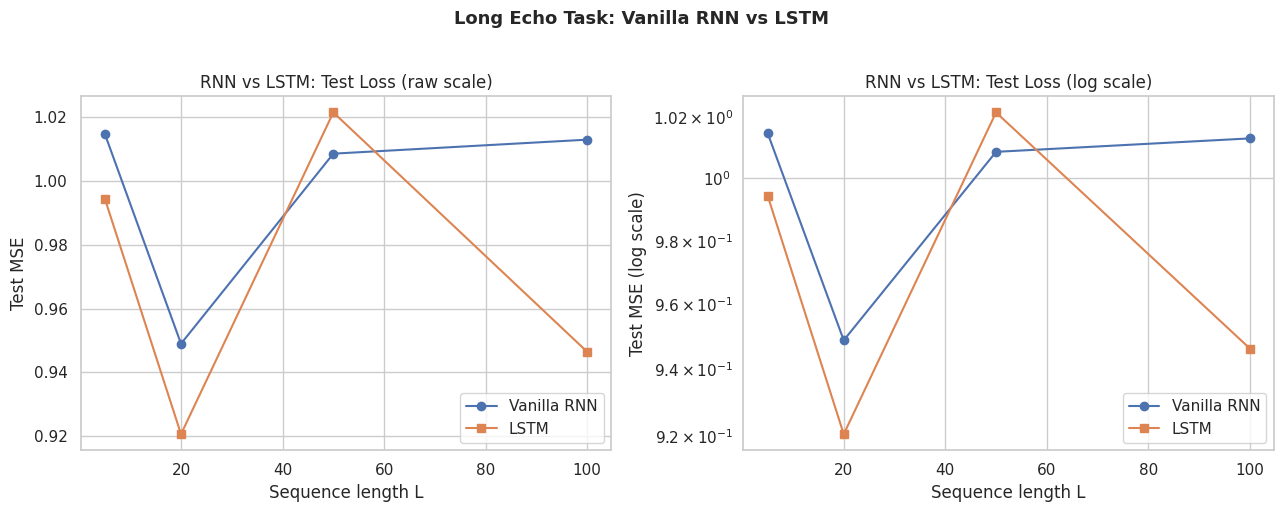


     L        RNN MSE       LSTM MSE   Ratio (RNN/LSTM)
--------------------------------------------------------
     5       1.014803       0.994452                1.0x
    20       0.948946       0.920550                1.0x
    50       1.008619       1.021569                1.0x
   100       1.013017       0.946414                1.1x


In [70]:
# Compare RNN vs LSTM on the Long Echo task
lengths = list(echo_results.keys())
rnn_losses  = [echo_results[L]["test_loss"] for L in lengths]
lstm_losses = [lstm_echo_results[L]["test_loss"] for L in lengths]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: raw scale
ax = axes[0]
ax.plot(lengths, rnn_losses,  marker="o", label="Vanilla RNN")
ax.plot(lengths, lstm_losses, marker="s", label="LSTM")
ax.set_xlabel("Sequence length L")
ax.set_ylabel("Test MSE")
ax.set_title("RNN vs LSTM: Test Loss (raw scale)")
ax.legend()

# Right: log scale to reveal the orders-of-magnitude difference
ax = axes[1]
ax.semilogy(lengths, rnn_losses,  marker="o", label="Vanilla RNN")
ax.semilogy(lengths, lstm_losses, marker="s", label="LSTM")
ax.set_xlabel("Sequence length L")
ax.set_ylabel("Test MSE (log scale)")
ax.set_title("RNN vs LSTM: Test Loss (log scale)")
ax.legend()

plt.suptitle("Long Echo Task: Vanilla RNN vs LSTM", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Print numeric comparison
print(f"\n{'L':>6} {'RNN MSE':>14} {'LSTM MSE':>14} {'Ratio (RNN/LSTM)':>18}")
print("-" * 56)
for L in lengths:
    r = echo_results[L]["test_loss"]
    l = lstm_echo_results[L]["test_loss"]
    ratio = r / l if l > 0 else float("inf")
    print(f"{L:>6} {r:>14.6f} {l:>14.6f} {ratio:>18.1f}x")

In [ ]:
show_todo("Answer the Challenge 5 analysis question")

**Q1:** Compare the LSTM's performance to the vanilla RNN on the Long Echo task. At which sequence lengths does the LSTM outperform the RNN? Why does the LSTM succeed where the RNN fails?

**ANSWER:**
The LSTM outperforms the vanilla RNN at almost every sequence length, but the difference is dramatic at L=100. At short sequences (L=5), both models perform similarly because the gradient signal does not have far to travel. At L=20, both MSEs drop. At L=50 and L=100, the vanilla RNN essentially fails — its loss increases dramatically, meaning it has learned nothing useful, whereas the LSTM has its MSE decrease at L=100.

The LSTM succeeds because of its **cell state** $c_t$, a separate memory channel that allows gradients to flow backward with minimal decay (shortcut/highway). The **forget gate** and **input gate** learn to selectively preserve important information (like $x_0$) across many time steps without repeatedly multiplying it through a saturating nonlinearity. In contrast, the vanilla RNN propagates information exclusively through $h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t)$: every step applies the same $\tanh$ and the same weight matrix, which squashes and mixes the signal until $x_0$ is unrecoverable. The LSTM's gating mechanism provides a shortcut that avoids this repeated squashing.
<br>

In [ ]:
show_section()

# Career Survey

Read: [How to Stay Ahead of AI as an Early-Career Engineer](https://spectrum.ieee.org/ai-effect-entry-level-jobs), from IEEE Spectrum, Dec 25, 2025. 

Then, choose one of the following prompts, and answer it below in 100-200 of YOUR OWN words. 

> PLEASE! No more AI crap for **Career Survey** and **Society** sections!

**Prompt 1:** Programmer employment fell 27.5% from 2023–2025, while software developer employment fell only 0.3%. The article argues these are distinct roles: programmers execute, whereas developers and engineers design and reason. Given what you've done in this course and elsewhere, i.e. building architectures, diagnosing training failures, delving into questionable outputs, visualiing and explaining models, designing experiments, etc., which side of that divide do you think you're being trained for?

**Prompt 2:** The article reports that 61% of employers say they are not replacing entry-level jobs with AI — yet entry-level hiring at the top 15 tech firms fell 25% in a single year. How do you reconcile those two facts? What might explain the gap between what employers say and what the hiring data shows? Does this change how much you trust employer statements about AI and jobs?

**Prompt 3:** Roberts warns that if companies stop hiring junior engineers today, there will be no mid-level engineers in five years. From the employer side, the counterargument is that AI handles what juniors used to do. Are employers being short sighted? If they really stop hiring junior engineers, where will they be in five years? Are they just expecting AI to continue to grow

**ANSWER:**
<br>
Prompt 2: I would argue that the reason entry-level hiring fell at the top 15 tech firms because of their mistake of overhiring and trying to boost their stock prices. With news of layoffs, stock prices usually skyrockets as seen in Block's case. Firms may be incentivized to do this to please investors while also being able to cut people who may not be contributing as much to the company. However, this is a dangerous move as it could lead to rehiring (just like Block did recently). Yes, this makes me skeptical of employers and whether they are truly laying people off because of the productivity boosts seen with AI.
<br>




In [ ]:
show_section()

# Society

Read: [Key findings about how Americans view artificial intelligence](https://www.pewresearch.org/short-reads/2026/03/12/key-findings-about-how-americans-view-artificial-intelligence/) from Pew Research Center, March 12, 2026. 

Then, choose one of the following prompts, and answer it below in 100-200 of YOUR OWN words.

**Prompt 1:** The article reports that 50% of Americans are "more concerned than excited" about AI, up from 37% in 2021. What factors do you think are driving this trend? Is growing concern a rational response to new information, or is it driven by media framing and hype?

**Prompt 2:** 64% of teens use AI chatbots, and 60% of Americans believe students use them to cheat. You are a student using AI in a course about building AI. Reflect honestly: where is the line between using AI as a legitimate learning tool and using it in a way that undermines your own education? Does that line

**Prompt 3:** About half of Americans believe AI will worsen people's ability to think creatively and form meaningful relationships. Do you agree? Can you find evidence from your own experience (or from AI research literature) that supports or refutes this?

**Prompt 4:** 54% of Republicans trust the U.S. government to regulate AI well, compared to only 36% of Democrats. THis is a striking reversal of the typical partisan pattern on government regulation. What do you think explains this gap? Is it about who currently holds power, deeper philosophical differences about technology and markets, or something else? And set aside party affiliation for a moment: do you trust the government — or any single institution — to regulate AI effectively? If not, who or what should be doing it?  



**ANSWER:**
<br>
Prompt 3: I would agree that AI will worsen people's critical thinking skills and their creativity. However, this will only happen if people start using AI without restriction. If they try to rely AI for every single thing they do, people will not exercise their brain. I have been a victim to this earlier when ChatGPT was released. I quickly remediated this by mainly using AI to examine my thoughts and work to get feedback unless I am in a time crunch. I constantly push back on AI to make sure that it is making sense.
<br>




# AI Usage Disclosure

**IDE or browser-based environment used:** VSCode

**AI tools used:** Claude

**Short reflection:**
How did you use AI this week? Did it help you understand RNNs, time series data engineering, or the vanishing gradient problem? Did it help debug your engine extensions? Be specific about what worked well and what didn't.

I mainly used it for syntax for libraries I don't know and to explain certain concepts.

**AI Chat Dialogs:**
(Paste relevant snippets here - particularly any that helped you understand conceptual questions or debug code)

<br>
1.

```
Complete this code:
# TODO: Generate a synthetic time series as a simple numpy array. It should represent
# a sine wave with minor noise. Generate a 2 second sample of a sin wave that has a 
# frequency of 5 Hz. Sample the sine wave at 1 kHz. Plot the series and print the range of values.
# Store your numpy array in `raw_series`.

raw_series = 

# TODO: Plot the series.
???

# Print the length and value range of the series.
print(f"Series length: {len(raw_series)}")
print(f"Value range:   [{raw_series.min():.3f}, {raw_series.max():.3f}]")
Show less
3:35 PM
Here's the completed code:

python
import numpy as np
import matplotlib.pyplot as plt

# 1 kHz sample rate, 2 second duration → 2000 samples
t = np.linspace(0, 2, 2000, endpoint=False)  # time axis in seconds

# 5 Hz sine wave + small Gaussian noise
raw_series = np.sin(2 * np.pi * 5 * t) + np.random.normal(0, 0.05, size=len(t))

# Plot
plt.figure(figsize=(12, 4))
plt.plot(t, raw_series, linewidth=0.8)
plt.title("5 Hz Sine Wave with Noise (2 seconds @ 1 kHz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

# Print the length and value range of the series.
print(f"Series length: {len(raw_series)}")
print(f"Value range:   [{raw_series.min():.3f}, {raw_series.max():.3f}]")
```



# Clean shutdown for Colab

In [ ]:
if IN_COLAB:
    from google.colab import runtime
    print("Disconnecting runtime...")
    runtime.unassign()
else:
    print("Not running in Colab, skipping disconnect.")